
# <div style="text-align:center; color:Black; font-weight:bold;">Introducción al Proyecto de aula</div>
# <div style="text-align:center; color:Black; font-weight:bold;">Análisis exploratorio EDA</div>



La base de datos seleccionada fue **[Car Price](https://www.kaggle.com/datasets/yaaryiitturan/auto-scout-car-price)**
disponible en la plataforma Kaggle. Este dataset recopila información de vehículos nuevos y usados ofertados en la compañía Europea AutoScout24 durante el año 2019. Incluye variables técnicas y comerciales relevantes como la marca, modelo, años de uso, kilometraje, tipo de combustible, potencia del motor, transmisión, entre otras.

Mediante las variables disponibles en la base datos, es posible realizar un análisis de cuáles de estas características se asocian de manera más significativa con el precio final de los autos, permitiendo responder a la pregunta de investigación planteada y aportar evidencia sobre los factores que más influyen en la valoración del mercado automotriz.

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:20px">
<b>Pregunta de investigación</b><br>
</div>

¿Cuáles son las principales variables que influyen en el precio de los autos publicados en la plataforma AutoScout24 durante el año 2019?
<br> 


<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:20px">
<b>Tabla descriptiva de las variables</b><br>
</div>


<p style="text-align:center;">
  <img src="imgs/tabla.jpg" alt="bannersp" style="width:60%; border-radius:10px;">
</p>

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>Fuente de los datos</b><br>
</div>

- Dataset: **Auto Scout Car Price**
  **Repositorio:** [UCI Machine Learning Repository](https://www.kaggle.com/datasets/yaaryiitturan/auto-scout-car-price).  
  **Autores:** Yaaryiitturan Kaggle  
  **Descripción:** Este conjunto de datos proporciona información completa sobre anuncios de autos usados, incluyendo especificaciones, características, precios y más. Resulta valioso para analizar precios, tendencias y preferencias de los clientes en el mercado automotriz. Los datos se recopilaron en 2019 de la empresa de comercio de automóviles en línea AutoScout24 y contienen muchas características de 9 modelos de automóviles diferentes.

En la selección de variables se optó por seleccionar una variable categórica y transformarla en discreta por ejemplo con la siguiente relación:
1. Benzine (gasolina)
2. Diesel
3. Electric
4. Gas

Esto debido a la importancia de la elección del precio de un auto, por este tipo de característica.

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:20px">
<b>Carga de los datos</b><br>
</div>

In [1]:
# Uso de Librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import skew, kurtosis
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from numpy.linalg import svd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import LocalOutlierFactor
from scipy.stats import chi2_contingency
from kmodes.kmodes import KModes

In [2]:
# Estilo general
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Crear dataset
df = pd.read_csv("../datos/dataset_depurado.csv", sep=";")

<Figure size 1200x600 with 0 Axes>

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>Visualización de los datos</b><br>
</div>

In [3]:
# Visualizar una pequeña muestra de los datos
df.head()

,price,km,Fuel,Gears,age,Previous_Owners,hp_kW,Inspection_new,Displacement_cc,Weight_kg,cons_comb
0,15770,56013.0,Diesel,7,3,2,66,1,1422,1220,3.8
1,14500,80000.0,Benzine,7,2,1,141,0,1798,1255,5.6
2,14640,83450.0,Diesel,7,3,1,85,0,1598,1135,3.8
3,14500,73000.0,Diesel,6,3,1,66,0,1422,1195,3.8
4,16790,16200.0,Diesel,7,3,1,66,1,1422,1135,4.1


<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>Número de registros y variables</b><br>
</div>

In [4]:
# Número de registros y variables
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

Número de registros: 15915
Número de variables: 11


<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>Tipos de datos</b><br>
</div>

In [5]:
# Tipos de datos
print("\nTipos de datos por variable:")
print(df.dtypes.value_counts())


Tipos de datos por variable:
int64      8
float64    2
object     1
Name: count, dtype: int64


<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>Clasificación de variables</b><br>
</div>

In [6]:
# Clasificación de variables
categoricas = df.select_dtypes(include=['object']).columns.tolist()
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("🔹 Variables categóricas:")
print("\n".join([f"- {col}" for col in categoricas]))

print("\n🔸 Variables numéricas:")
print("\n".join([f"- {col}" for col in numericas]))

🔹 Variables categóricas:
- Fuel

🔸 Variables numéricas:
- price
- km
- Gears
- age
- Previous_Owners
- hp_kW
- Inspection_new
- Displacement_cc
- Weight_kg
- cons_comb


<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>Descripción General de variables numéricas</b><br>
</div>

In [7]:
# Descripción general
print("\nDescripción de variables numéricas:")
print(df.describe())


Descripción de variables numéricas:
              price             km         Gears           age  \
count  15915.000000   15915.000000  15915.000000  15915.000000   
mean   18024.380584   32089.995708      5.937355      1.389695   
std     7381.679318   36977.214964      0.704772      1.121306   
min     4950.000000       0.000000      5.000000      0.000000   
25%    12850.000000    1920.500000      5.000000      0.000000   
50%    16900.000000   20413.000000      6.000000      1.000000   
75%    21900.000000   46900.000000      6.000000      2.000000   
max    74600.000000  317000.000000      8.000000      3.000000   

       Previous_Owners         hp_kW  Inspection_new  Displacement_cc  \
count     15915.000000  15915.000000    15915.000000     15915.000000   
mean          1.042853     88.499340        0.247063      1428.661891   
std           0.339178     26.674341        0.431317       275.804272   
min           0.000000     40.000000        0.000000       890.000000   
25%

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>Conteo de valores faltantes</b><br>
</div>

In [8]:
# Conteo de valores faltantes ordenado de mayor a menor
faltantes = df.isnull().sum().sort_values(ascending=False)

print("\nConteo de valores faltantes por variable:")
print(faltantes[faltantes > 0])  # Solo muestra variables con al menos un valor faltante


Conteo de valores faltantes por variable:
Series([], dtype: int64)


Las variables no presentan valores faltantes.

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>Conteo de valores únicos por variable</b><br>
</div>

In [9]:
# Conteo de valores únicos por variable
print("\nConteo de valores únicos por variable:")
print(df.nunique().sort_values(ascending=False))


Conteo de valores únicos por variable:
km                 6691
price              2952
Weight_kg           432
hp_kW                77
Displacement_cc      68
cons_comb            61
Previous_Owners       5
Fuel                  4
age                   4
Gears                 4
Inspection_new        2
dtype: int64


<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:20px">
<b>Análisis Univariado</b><br>
</div>

Se procede a analizar las variables continuas, mediante las Medidas de Tendencia Central(Media, Mediana y Moda) y Medidas de Dispersión (Rango, Varianza, Desviación estándar y Coeficiente de variación)

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:18px">
<b>Variables continuas</b><br>
</div>

<p style="text-align:center;">
  <img src="imgs/tabla4.jpg" alt="bannersp" style="width:60%; border-radius:10px;">
</p>

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>Precio</b><br>
</div>

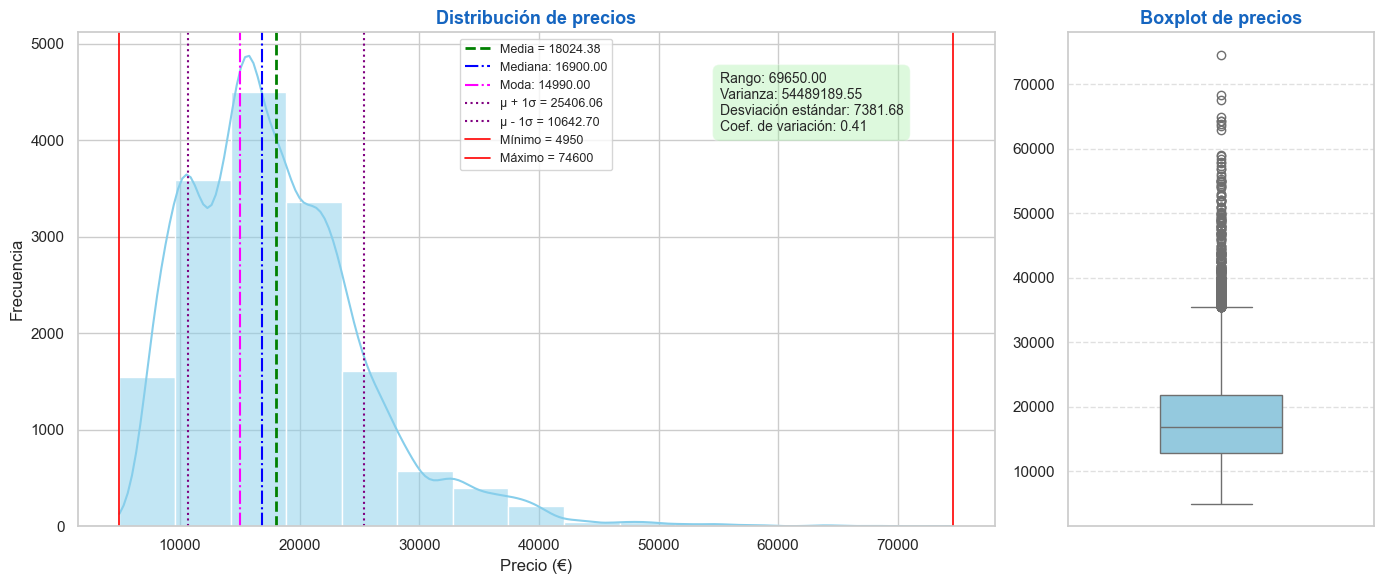

In [10]:
# Cálculo de medidas descriptivas
media = np.mean(df['price'])
mediana = np.median(df['price'])
moda = stats.mode(df['price'], keepdims=True).mode[0]
minimo = np.min(df['price'])
maximo = np.max(df['price'])
rango = maximo - minimo
varianza = np.var(df['price'], ddof=1)
desviacion = np.std(df['price'], ddof=1)
coef_var = desviacion / media

# Visualización 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 1]})
fig.subplots_adjust(wspace=0.3)

# Histograma
sns.histplot(df['price'], bins=15, kde=True, color='skyblue', ax=axes[0])

# Líneas verticales de referencia
axes[0].axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
axes[0].axvline(mediana, color='blue', linestyle='-.', label=f'Mediana: {mediana:.2f}')
axes[0].axvline(moda, color='magenta', linestyle='-.', label=f'Moda: {moda:.2f}')
axes[0].axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ + 1σ = {media + desviacion:.2f}')
axes[0].axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ - 1σ = {media - desviacion:.2f}')
axes[0].axvline(minimo, color='red', linestyle='-', linewidth=1.2, label=f'Mínimo = {minimo:.0f}')
axes[0].axvline(maximo, color='red', linestyle='-', linewidth=1.2, label=f'Máximo = {maximo:.0f}')

# Título y etiquetas
axes[0].set_title("Distribución de precios", fontsize=13, weight='bold', color='#1565C0')
axes[0].set_xlabel("Precio (€)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend(fontsize=9)

# Recuadro con medidas estadísticas
texto = (
    f"Rango: {rango:.2f}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
axes[0].text(
    0.7, 0.8, texto, transform=axes[0].transAxes,
    bbox=dict(facecolor='lightgreen', alpha=0.3, boxstyle="round,pad=0.5"),
    fontsize=10
)

# Boxplot 
sns.boxplot(y=df['price'], color='skyblue', width=0.4, ax=axes[1])
axes[1].set_title("Boxplot de precios", fontsize=13, weight='bold', color='#1565C0')
axes[1].set_ylabel("")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()


### <span style="color:Black;"><strong>Interpretación</strong></span>
 
Variable price (precio del auto en euros)
 
- Media = 18024 y Mediana = 16900; la media es mayor que la mediana lo que determina que la distribución esta sesgada a la derecha.
- La moda es más baja, con un valor de 14990 euros lo que muestra que hay cierta concentración de precios menores al promedio.
- Rango muy grande (4,950 a 74,600) lo que hace referencia a que presenta alta variabilidad.
- El CV es igaul a 41%, lo que muestra que la variable presenta una variación moderada alta.
- En el histograma, se observa una concentración importante de precios entre los 10000 y 30000 euros.


<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>Kilometraje</b><br>
</div>


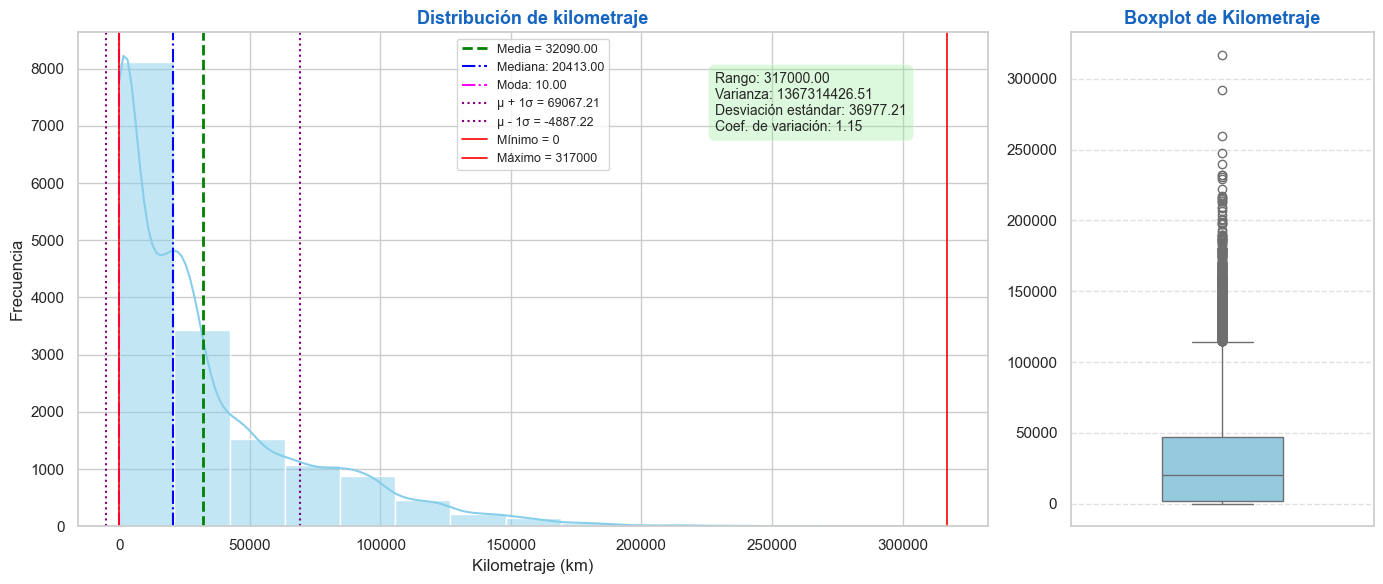

In [11]:
# Cálculo de medidas descriptivas
media = np.mean(df['km'])
mediana = np.median(df['km'])
moda = stats.mode(df['km'], keepdims=True).mode[0]
minimo = np.min(df['km'])
maximo = np.max(df['km'])
rango = maximo - minimo
varianza = np.var(df['km'], ddof=1)
desviacion = np.std(df['km'], ddof=1)
coef_var = desviacion / media


# Visualización 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 1]})
fig.subplots_adjust(wspace=0.3)

# Histograma
sns.histplot(df['km'], bins=15, kde=True, color='skyblue', ax=axes[0])

# Líneas verticales de referencia
axes[0].axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
axes[0].axvline(mediana, color='blue', linestyle='-.', label=f'Mediana: {mediana:.2f}')
axes[0].axvline(moda, color='magenta', linestyle='-.', label=f'Moda: {moda:.2f}')
axes[0].axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ + 1σ = {media + desviacion:.2f}')
axes[0].axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ - 1σ = {media - desviacion:.2f}')
axes[0].axvline(minimo, color='red', linestyle='-', linewidth=1.2, label=f'Mínimo = {minimo:.0f}')
axes[0].axvline(maximo, color='red', linestyle='-', linewidth=1.2, label=f'Máximo = {maximo:.0f}')

# Título y etiquetas
axes[0].set_title("Distribución de kilometraje", fontsize=13, weight='bold', color='#1565C0')
axes[0].set_xlabel("Kilometraje (km)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend(fontsize=9)

# Recuadro con medidas estadísticas
texto = (
    f"Rango: {rango:.2f}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
axes[0].text(
    0.7, 0.8, texto, transform=axes[0].transAxes,
    bbox=dict(facecolor='lightgreen', alpha=0.3, boxstyle="round,pad=0.5"),
    fontsize=10
)

# Boxplot
sns.boxplot(y=df['km'], color='skyblue', width=0.4, ax=axes[1])
axes[1].set_title("Boxplot de Kilometraje", fontsize=13, weight='bold', color='#1565C0')
axes[1].set_ylabel("")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

### <span style="color:Black;"><strong>Interpretación</strong></span>
 
 Variable km (kilometraje del auto)
 
- Media = 32090 y Mediana = 20413; la media es mayor que la mediana lo que determina que la distribución esta fuertemente sesgada a la derecha.
- La moda es mucho más baja, con un valor de 10 kilómetros lo que muestra que hay cierta concentración de km menores al promedio.
- Rango muy grande (0 a 317,000), presenta muy alta variabilidad.
- El CV tiene una valor de 115%, presenta una variación considerada alta, lo que hace que sea una variable muy dispersa y poco homogénea.
- En el histograma, se observa una concentración importante de km entre los 0 y 50000 km.


<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>Potencia</b><br>
</div>

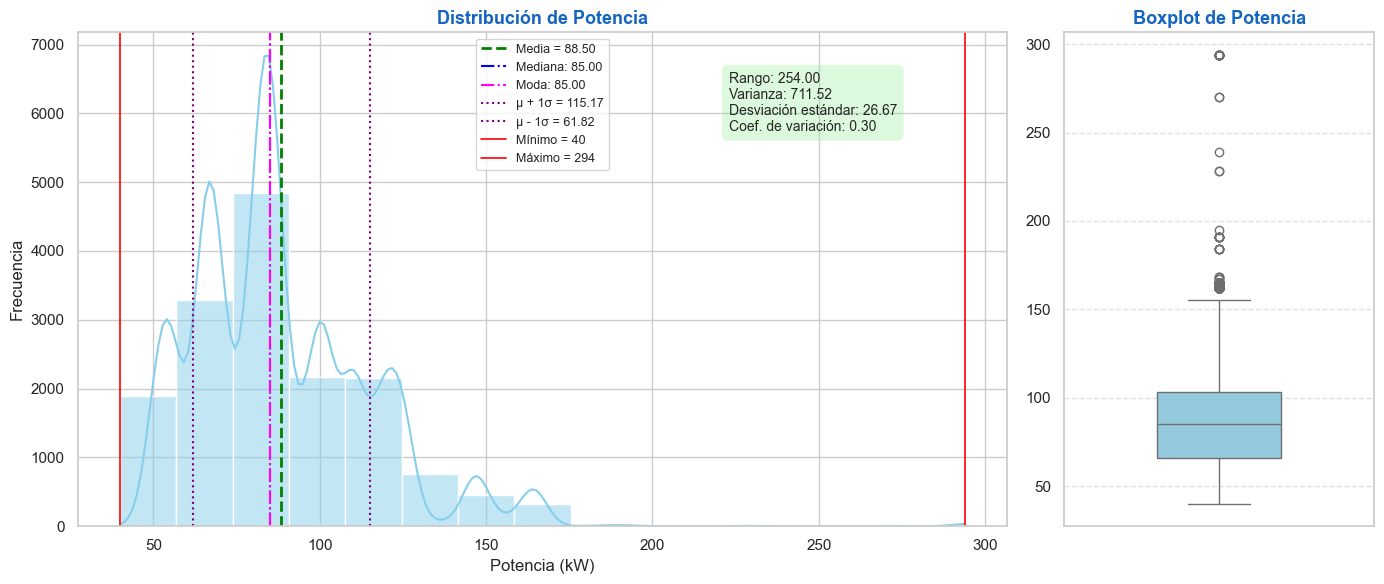

In [12]:
# Cálculo de medidas descriptivas
media = np.mean(df['hp_kW'])
mediana = np.median(df['hp_kW'])
moda = stats.mode(df['hp_kW'], keepdims=True).mode[0]
minimo = np.min(df['hp_kW'])
maximo = np.max(df['hp_kW'])
rango = maximo - minimo
varianza = np.var(df['hp_kW'], ddof=1)
desviacion = np.std(df['hp_kW'], ddof=1)
coef_var = desviacion / media


# Visualización 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 1]})
fig.subplots_adjust(wspace=0.3)

# Histograma
sns.histplot(df['hp_kW'], bins=15, kde=True, color='skyblue', ax=axes[0])

# Líneas verticales de referencia
axes[0].axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
axes[0].axvline(mediana, color='blue', linestyle='-.', label=f'Mediana: {mediana:.2f}')
axes[0].axvline(moda, color='magenta', linestyle='-.', label=f'Moda: {moda:.2f}')
axes[0].axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ + 1σ = {media + desviacion:.2f}')
axes[0].axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ - 1σ = {media - desviacion:.2f}')
axes[0].axvline(minimo, color='red', linestyle='-', linewidth=1.2, label=f'Mínimo = {minimo:.0f}')
axes[0].axvline(maximo, color='red', linestyle='-', linewidth=1.2, label=f'Máximo = {maximo:.0f}')

# Título y etiquetas
axes[0].set_title("Distribución de Potencia", fontsize=13, weight='bold', color='#1565C0')
axes[0].set_xlabel("Potencia (kW)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend(fontsize=9)

# Recuadro con medidas estadísticas
texto = (
    f"Rango: {rango:.2f}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
axes[0].text(
    0.7, 0.8, texto, transform=axes[0].transAxes,
    bbox=dict(facecolor='lightgreen', alpha=0.3, boxstyle="round,pad=0.5"),
    fontsize=10
)

# Boxplot
sns.boxplot(y=df['hp_kW'], color='skyblue', width=0.4, ax=axes[1])
axes[1].set_title("Boxplot de Potencia", fontsize=13, weight='bold', color='#1565C0')
axes[1].set_ylabel("")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

### <span style="color:Black;"><strong>Interpretación</strong></span>
 
 Variable hp_kW (Potencia del auto medida en kW)
 
- Media = 88.5 y Mediana = 85; la variable esta bastante centrada por la cercanía entre estas dos medidas, además la moda 85, pero igual presenta  sesgo a la derecha
- El Rango va de (40 a 294), presenta baja variabilidad.
- El CV es 30%, presenta una variabilidad moderada. 
- En el histograma, se observa una concentración importante de hp_kW entre los 60 y 120.

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>Cilindraje</b><br>
</div>

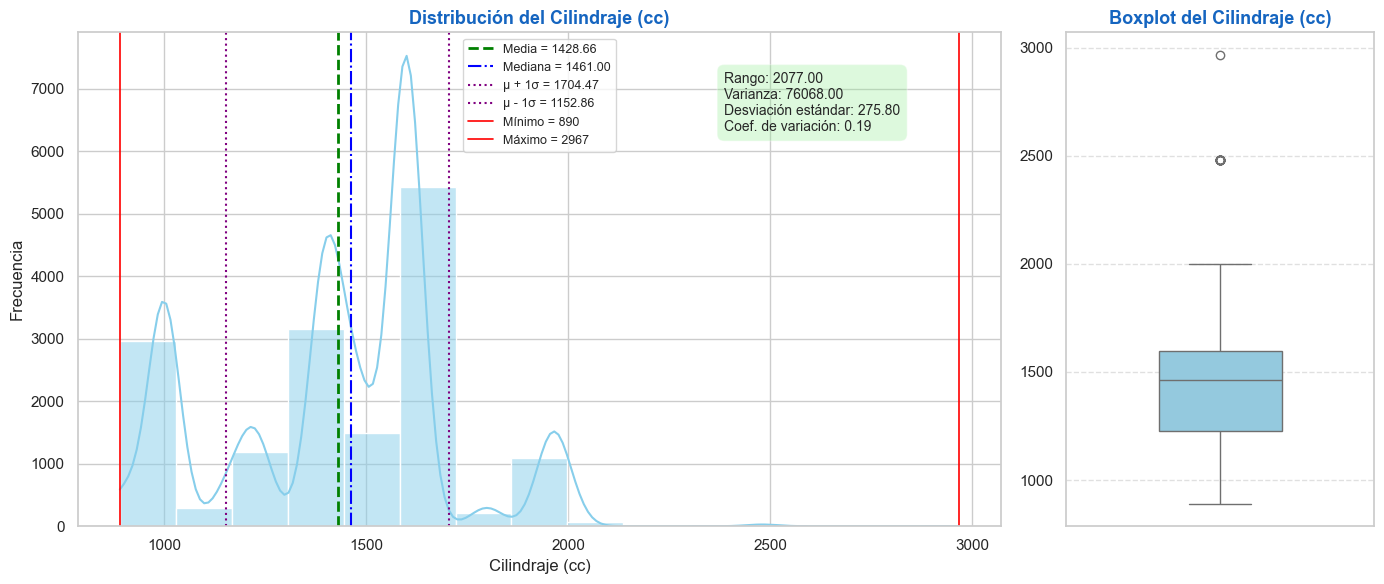

In [13]:
# Cálculo de medidas descriptivas
media = np.mean(df['Displacement_cc'])
mediana = np.median(df['Displacement_cc'])
minimo = np.min(df['Displacement_cc'])
maximo = np.max(df['Displacement_cc'])
rango = maximo - minimo
varianza = np.var(df['Displacement_cc'], ddof=1)
desviacion = np.std(df['Displacement_cc'], ddof=1)
coef_var = desviacion / media

# Visualización 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 1]})
fig.subplots_adjust(wspace=0.3)

# Histograma
sns.histplot(df['Displacement_cc'], bins=15, kde=True, color='skyblue', ax=axes[0])

# Líneas verticales
axes[0].axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
axes[0].axvline(mediana, color='blue', linestyle='-.', label=f'Mediana = {mediana:.2f}')
axes[0].axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ + 1σ = {media + desviacion:.2f}')
axes[0].axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ - 1σ = {media - desviacion:.2f}')
axes[0].axvline(minimo, color='red', linestyle='-', linewidth=1.2, label=f'Mínimo = {minimo:.0f}')
axes[0].axvline(maximo, color='red', linestyle='-', linewidth=1.2, label=f'Máximo = {maximo:.0f}')

# Título y etiquetas
axes[0].set_title("Distribución del Cilindraje (cc)", fontsize=13, weight='bold', color='#1565C0')
axes[0].set_xlabel("Cilindraje (cc)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend(fontsize=9)

# Recuadro con medidas estadísticas
texto = (
    f"Rango: {rango:.2f}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
axes[0].text(0.7, 0.8, texto, transform=axes[0].transAxes,
             bbox=dict(facecolor='lightgreen', alpha=0.3, boxstyle='round,pad=0.5'), fontsize=10)

# Boxplot
sns.boxplot(y=df['Displacement_cc'], color='skyblue', width=0.4, ax=axes[1])
axes[1].set_title("Boxplot del Cilindraje (cc)", fontsize=13, weight='bold', color='#1565C0')
axes[1].set_ylabel("")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### <span style="color:Black;"><strong>Interpretación</strong></span>
 
 Variable Displacement_cc (Tamaño del motor en centímetros cúbicos)
 
- Media = 1429 y Mediana = 1461; valores muy cercanos, lo que da una posible distribución simétrica.
- Rango de (890 a 2967): presenta baja variabilidad.
- El CV es del 30%, presenta una baja variabilidad. 
- En el histograma, se observa una concentración importante de  Displacement_cc entre los 1152 y 1704, pero con valores significativos menores a 1000.


<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>Peso</b><br>
</div>

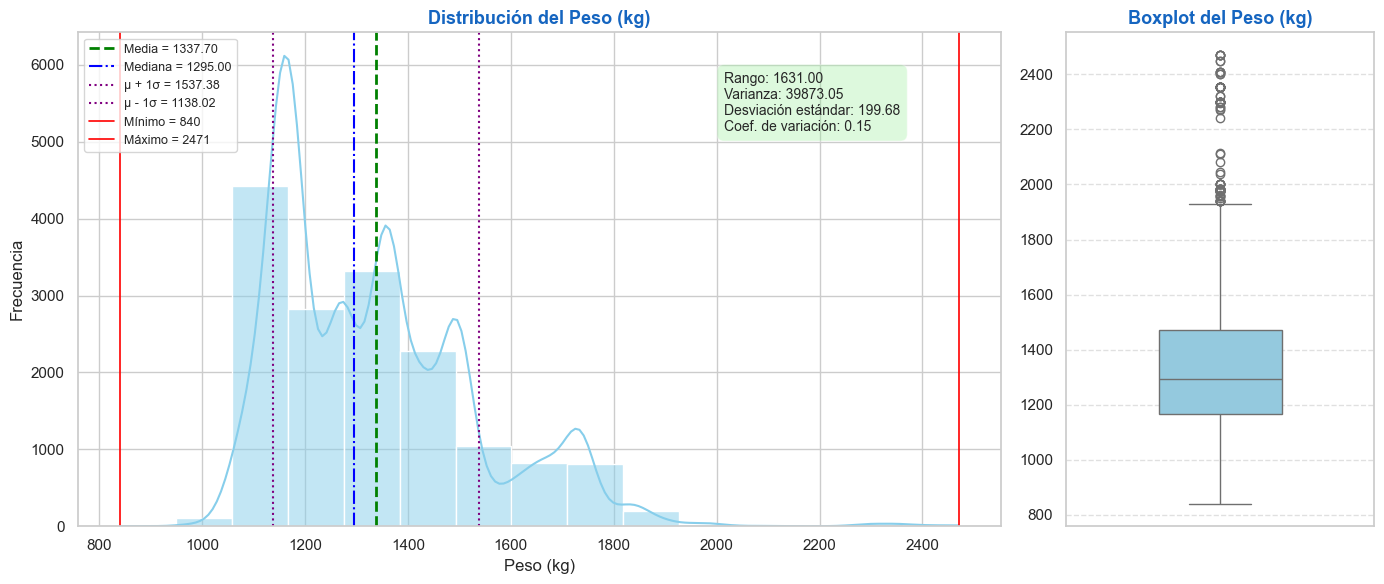

In [14]:
# Cálculo de medidas descriptivas
media = np.mean(df['Weight_kg'])
mediana = np.median(df['Weight_kg'])
minimo = np.min(df['Weight_kg'])
maximo = np.max(df['Weight_kg'])
rango = maximo - minimo
varianza = np.var(df['Weight_kg'], ddof=1)
desviacion = np.std(df['Weight_kg'], ddof=1)
coef_var = desviacion / media

# Visualización 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 1]})
fig.subplots_adjust(wspace=0.3)

# Histograma
sns.histplot(df['Weight_kg'], bins=15, kde=True, color='skyblue', ax=axes[0])

# Líneas verticales
axes[0].axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
axes[0].axvline(mediana, color='blue', linestyle='-.', label=f'Mediana = {mediana:.2f}')
axes[0].axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ + 1σ = {media + desviacion:.2f}')
axes[0].axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ - 1σ = {media - desviacion:.2f}')
axes[0].axvline(minimo, color='red', linestyle='-', linewidth=1.2, label=f'Mínimo = {minimo:.0f}')
axes[0].axvline(maximo, color='red', linestyle='-', linewidth=1.2, label=f'Máximo = {maximo:.0f}')

# Título y etiquetas
axes[0].set_title("Distribución del Peso (kg)", fontsize=13, weight='bold', color='#1565C0')
axes[0].set_xlabel("Peso (kg)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend(fontsize=9)

# Recuadro con medidas estadísticas
texto = (
    f"Rango: {rango:.2f}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
axes[0].text(0.7, 0.8, texto, transform=axes[0].transAxes,
             bbox=dict(facecolor='lightgreen', alpha=0.3, boxstyle='round,pad=0.5'), fontsize=10)

# Boxplot
sns.boxplot(y=df['Weight_kg'], color='skyblue', width=0.4, ax=axes[1])
axes[1].set_title("Boxplot del Peso (kg)", fontsize=13, weight='bold', color='#1565C0')
axes[1].set_ylabel("")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### <span style="color:Black;"><strong>Interpretación</strong></span>
 
 Variable Weight_kg (Peso del auto en kilogramos)
 
- Media = 1338 y Mediana = 1295; valores muy cercanos, lo que da una posible distribución simétrica.
- Rango de 840 a 2471, presenta baja variabilidad.
- El CV es del 15%, presenta una baja variabilidad, es decir presenta datos homogéneos. 
- En el histograma, se observa una concentración importante de  Weight_kg entre los 1100 y 1500 aproximadamente.


<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>Consumo de combustible</b><br>
</div>

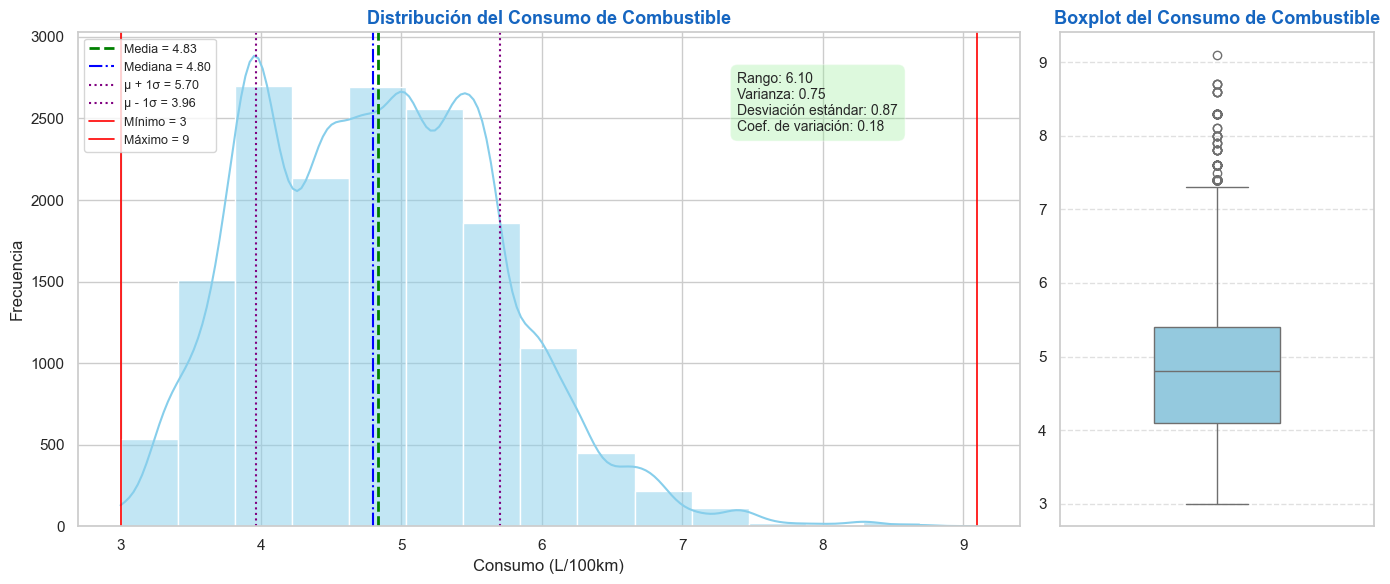

In [15]:
# Cálculo de medidas descriptivas
media = np.mean(df['cons_comb'])
mediana = np.median(df['cons_comb'])
minimo = np.min(df['cons_comb'])
maximo = np.max(df['cons_comb'])
rango = maximo - minimo
varianza = np.var(df['cons_comb'], ddof=1)
desviacion = np.std(df['cons_comb'], ddof=1)
coef_var = desviacion / media

# Visualización 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [3, 1]})
fig.subplots_adjust(wspace=0.3)

# Histograma
sns.histplot(df['cons_comb'], bins=15, kde=True, color='skyblue', ax=axes[0])

# Líneas verticales
axes[0].axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
axes[0].axvline(mediana, color='blue', linestyle='-.', label=f'Mediana = {mediana:.2f}')
axes[0].axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ + 1σ = {media + desviacion:.2f}')
axes[0].axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'µ - 1σ = {media - desviacion:.2f}')
axes[0].axvline(minimo, color='red', linestyle='-', linewidth=1.2, label=f'Mínimo = {minimo:.0f}')
axes[0].axvline(maximo, color='red', linestyle='-', linewidth=1.2, label=f'Máximo = {maximo:.0f}')

# Título y etiquetas
axes[0].set_title("Distribución del Consumo de Combustible", fontsize=13, weight='bold', color='#1565C0')
axes[0].set_xlabel("Consumo (L/100km)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend(fontsize=9)

# Recuadro con medidas estadísticas
texto = (
    f"Rango: {rango:.2f}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
axes[0].text(0.7, 0.8, texto, transform=axes[0].transAxes,
             bbox=dict(facecolor='lightgreen', alpha=0.3, boxstyle='round,pad=0.5'), fontsize=10)

# Boxplot
sns.boxplot(y=df['cons_comb'], color='skyblue', width=0.4, ax=axes[1])
axes[1].set_title("Boxplot del Consumo de Combustible", fontsize=13, weight='bold', color='#1565C0')
axes[1].set_ylabel("")
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### <span style="color:Black;"><strong>Interpretación</strong></span>
 
 Variable cons_comb (Consumo de combustible del auto en litros por cada 100 km)
 
- Media = 4.83 y Mediana = 4.8; valores muy cercanos, lo que da una posible distribución simétrica.
- Rango de 3 a 9, presenta baja variabilidad.
- Con un CV del 18%, presenta una baja variabilidad, es decir presenta datos homogéneos. 
- En el histograma, se observa una concentración importante de cons_comb entre los 4 y 6 aproximadamente.


<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:18px">
<b>Análisis de Distribución</b><br>
</div>

Se analizan las siguientes características de la distribución de las variables continuas:
1. Asimetría
2. Curtosis


In [16]:
# Variables continuas 
variables_continuas = ['price', 'km','hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb' ]

resultados = []

for var in variables_continuas:
    datos = df[var].dropna()
    asimetria = skew(datos)
    curtosis_valor = kurtosis(datos, fisher=True)
    resultados.append({
        'Variable': var,
        'Asimetría (Skew)': round(asimetria, 3),
        'Curtosis (Kurtosis)': round(curtosis_valor, 3)
        
    })

tabla_asim_curt = pd.DataFrame(resultados)
print(tabla_asim_curt)


          Variable  Asimetría (Skew)  Curtosis (Kurtosis)
0            price             1.236                2.964
1               km             1.623                2.824
2            hp_kW             1.292                4.385
3  Displacement_cc            -0.097               -0.202
4        Weight_kg             1.082                1.594
5        cons_comb             0.419                0.115


### <span style="color:Black;"><strong>Interpretación</strong></span>

<p style="text-align:center;">
  <img src="imgs/tabla2.jpg" alt="bannersp" style="width:60%; border-radius:10px;">
</p>

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:18px">
<b>Análisis de posición relativa</b><br>
</div>
Las medidas de posición representadas son:

1. Percentiles
2. Deciles
3. Cuartiles

C:\Users\Nitro V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


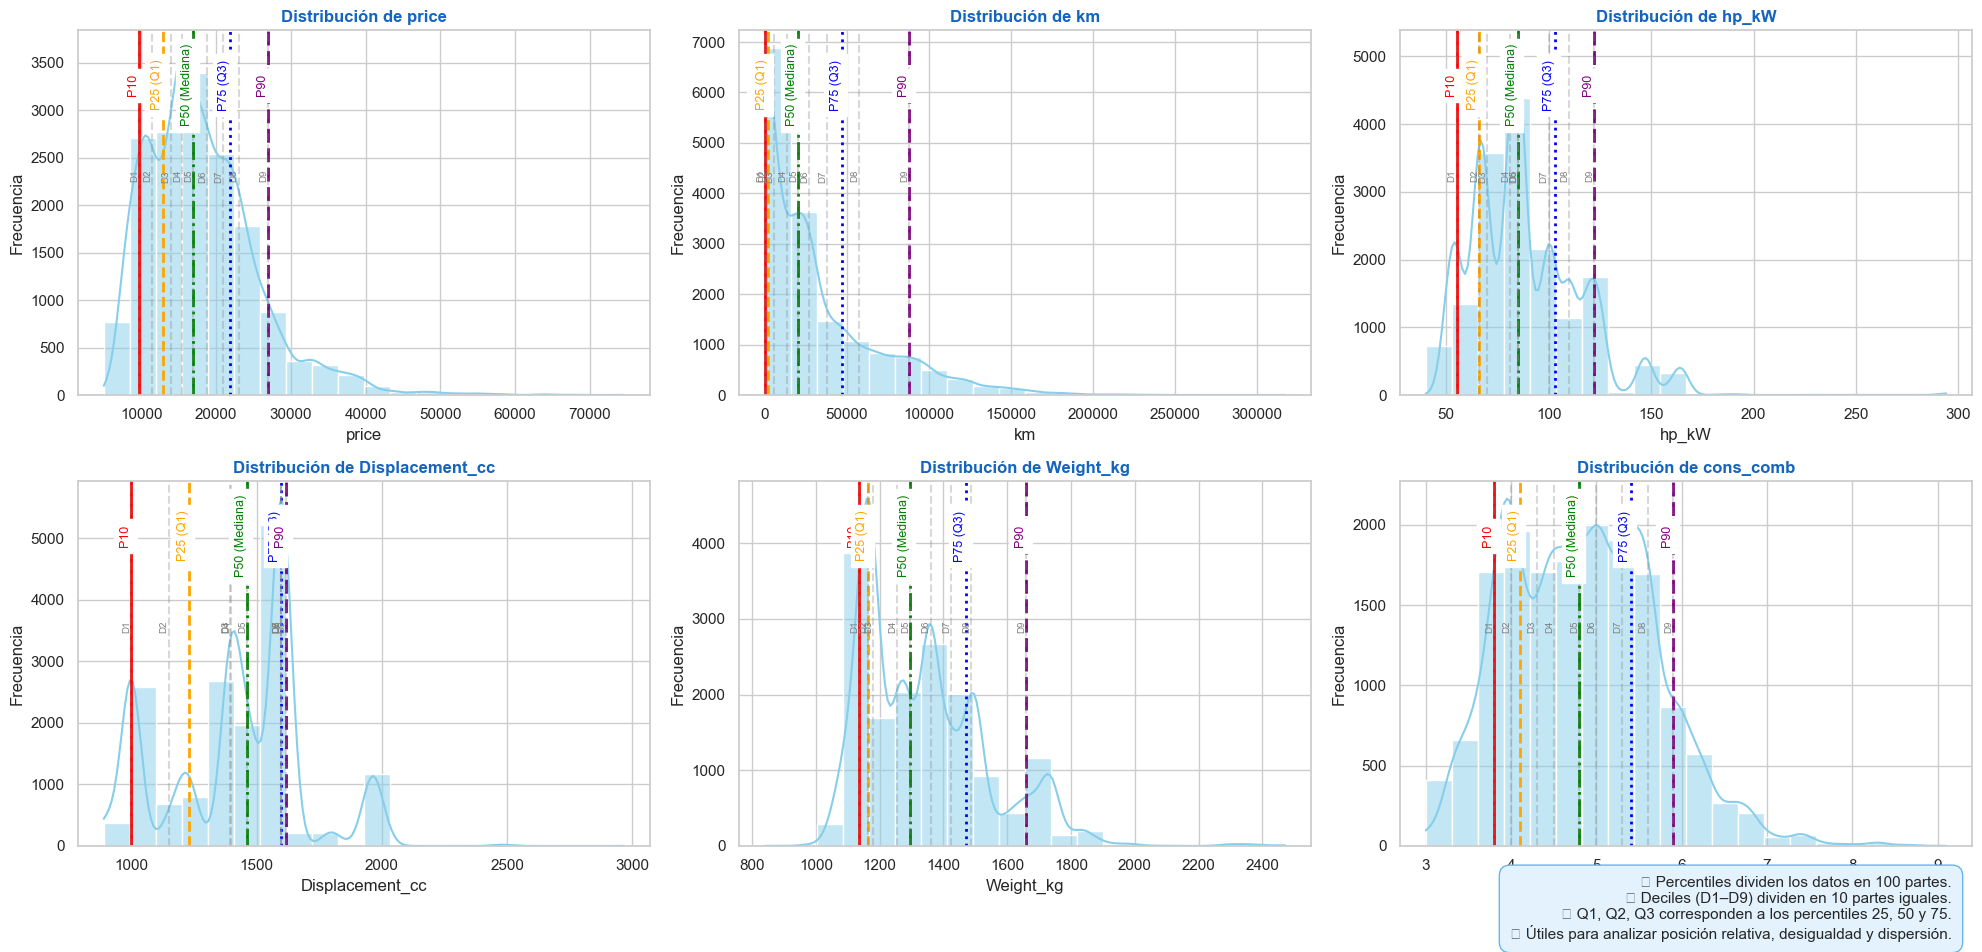

In [17]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, var in enumerate(variables_continuas):
    datos = df[var].dropna()
    
    # Percentiles clave
    percentiles = {
        'P10': {'valor': np.percentile(datos, 10), 'color': 'red', 'linestyle': '-'},
        'P25 (Q1)': {'valor': np.percentile(datos, 25), 'color': 'orange', 'linestyle': '--'},
        'P50 (Mediana)': {'valor': np.percentile(datos, 50), 'color': 'green', 'linestyle': '-.'},
        'P75 (Q3)': {'valor': np.percentile(datos, 75), 'color': 'blue', 'linestyle': ':'},
        'P90': {'valor': np.percentile(datos, 90), 'color': 'purple', 'linestyle': (0, (5, 2))}
    }

    # Deciles D1–D9
    deciles = {f'D{i}': np.percentile(datos, i * 10) for i in range(1, 10)}

    # Histograma con KDE
    sns.histplot(datos, kde=True, color='skyblue', bins=20, ax=axes[i])
    
    # Líneas para percentiles destacados
    for etiqueta, props in percentiles.items():
        axes[i].axvline(props['valor'], color=props['color'], linestyle=props['linestyle'], linewidth=2)
        axes[i].text(props['valor'], axes[i].get_ylim()[1]*0.85, etiqueta,
                     rotation=90, color=props['color'], fontsize=9,
                     verticalalignment='center', horizontalalignment='right',
                     backgroundcolor='white')
    
    # Líneas más sutiles para deciles
    for etiqueta, valor in deciles.items():
        axes[i].axvline(valor, color='gray', linestyle='--', alpha=0.3)
        axes[i].text(valor, axes[i].get_ylim()[1]*0.6, etiqueta,
                     rotation=90, color='gray', fontsize=7,
                     verticalalignment='center', horizontalalignment='right')

    # Título del subplot
    axes[i].set_title(f"Distribución de {var}", fontsize=12, fontweight='bold', color='#1565C0')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Frecuencia")

# Recuadro explicativo global
texto = (
    "🔹 Percentiles dividen los datos en 100 partes.\n"
    "🔹 Deciles (D1–D9) dividen en 10 partes iguales.\n"
    "🔹 Q1, Q2, Q3 corresponden a los percentiles 25, 50 y 75.\n"
    "🔹 Útiles para analizar posición relativa, desigualdad y dispersión."
)
fig.text(0.98, 0.05, texto, fontsize=11, verticalalignment='bottom',
         horizontalalignment='right', bbox=dict(boxstyle="round,pad=0.7", 
         facecolor="#E3F2FD", edgecolor="#64B5F6"))

# Ajustes finales
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


### <span style="color:Black;"><strong>Interpretación</strong></span>


#### <span style="color:black;"><strong>Percetiles</strong></span>
Como se puede observar los valores de las variables continuas, están en el 90% de los datos, es decir que presentan sesgo a la derecha, que pueden ser valores atípicos, y se necesita más análisis para determinar su tratamiento.

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:18px">
<b>Análisis de variables discretas</b><br>
</div>

C:\Users\Nitro V15\AppData\Local\Temp\ipykernel_43876\248020029.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], palette="pastel")
C:\Users\Nitro V15\AppData\Local\Temp\ipykernel_43876\248020029.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], palette="pastel")
C:\Users\Nitro V15\AppData\Local\Temp\ipykernel_43876\248020029.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[var], palette="pastel")
C:\Users\Nitro V15\AppData\Local\Temp\ipykernel_43876\248020029.py:7: FutureWarning: 

Passing `palette` w

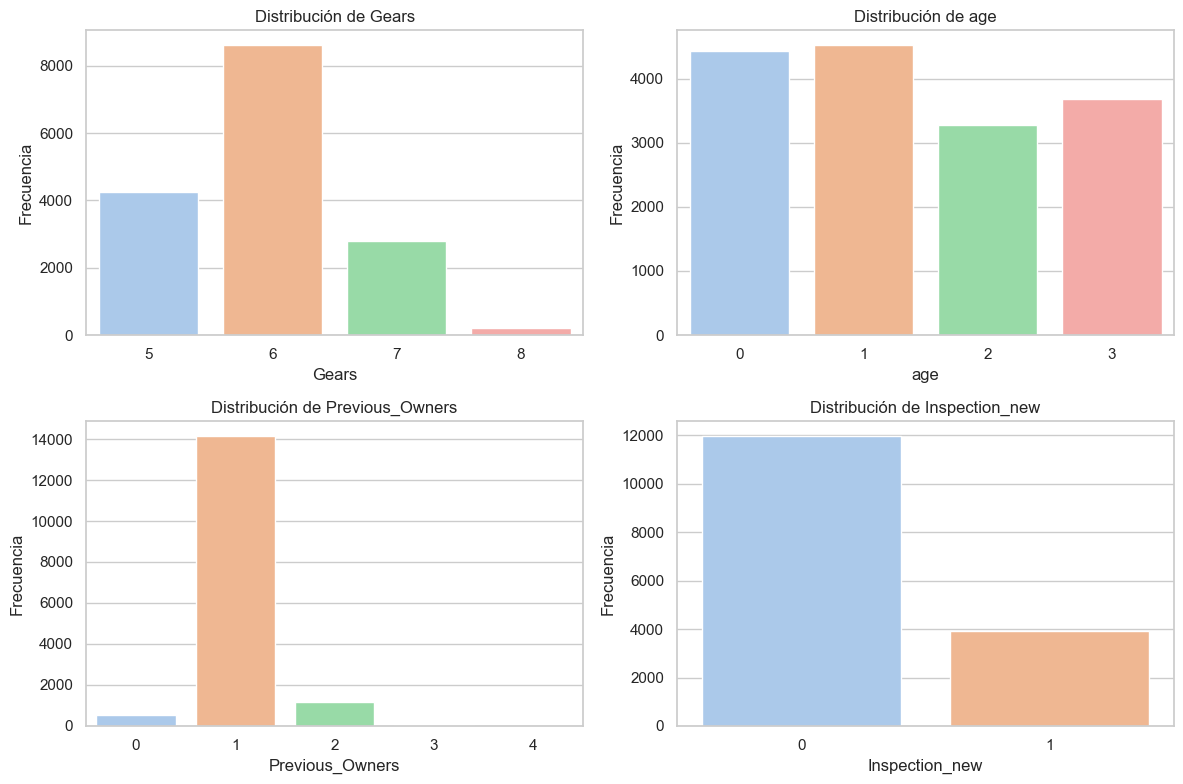

In [18]:
variables_discretas = ['Gears', 'age', 'Previous_Owners', 'Inspection_new']

plt.figure(figsize=(12, 8))

for i, var in enumerate(variables_discretas, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=df[var], palette="pastel")
    plt.title(f"Distribución de {var}")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()


### <span style="color:Black;"><strong>Interpretación</strong></span>

- La mayoría de los vehículos tiene 6 trasmisiones.
- La edad de los vehículos se distribuye casi homogéneamente de 0 a 3 años.
- La mayoría de los vehículos han tenido un solo anterior dueño.
- La mayoría de los autos no presentan inspección previa.

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:18px">
<b>Análisis de variable Cualitativa</b><br>
</div>

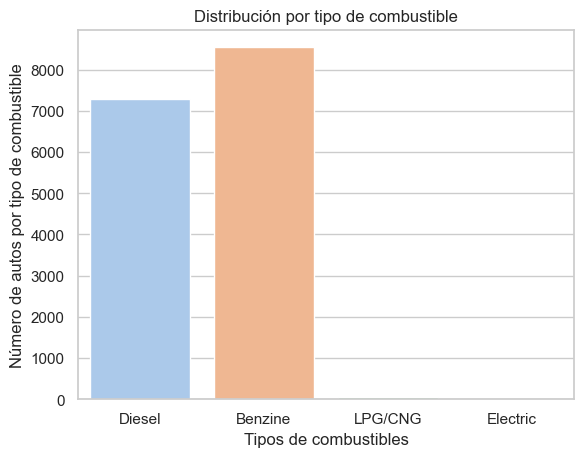

In [19]:
# Gráfico de barras: tipos de combustibles
sns.countplot(x='Fuel', data=df,hue='Fuel', palette='pastel',legend=False)
plt.title("Distribución por tipo de combustible")
plt.xlabel("Tipos de combustibles")
plt.ylabel("Número de autos por tipo de combustible")
plt.show()

### <span style="color:black;"><strong>Interpretación</strong></span>

- La mayoría de los vehículos son a gasolina seguido de Diesel, y presentan una pequeña cantidad a gas y a electricidad.

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:18px">
<b>Otros Análisis</b><br>
</div>

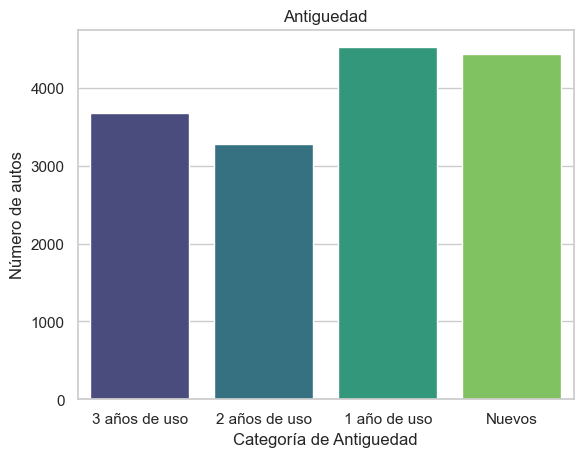

In [20]:
# Gráfico de barras: Antiguedad
# Mapeo de categorías
age_labels = {
    0: "Nuevos",
    1: "1 año de uso",
    2: "2 años de uso",
    3: "3 años de uso"
  }

# Columna con etiquetas
df['age_label'] = df['age'].map(age_labels)

# Gráfico 

sns.countplot(x='age_label',data=df,hue='age_label',palette='viridis',legend=False)
plt.title("Antiguedad")
plt.xlabel("Categoría de Antiguedad")
plt.ylabel("Número de autos")
plt.show()

### <span style="color:BLACK;"><strong>Interpretación</strong></span>

- De esta manera se interpreta mejor la variable edad

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:20px">
<b>Análisis Bivariado</b><br>
</div>

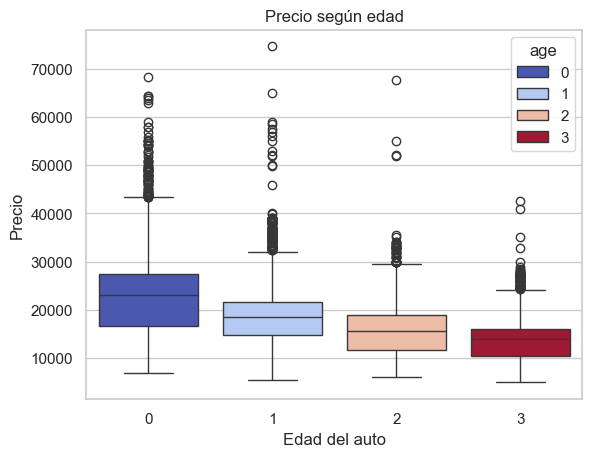

In [21]:
# Gráfico de dispersión: precio vs km
sns.boxplot(x='age', y='price',hue='age', data=df, palette='coolwarm')
plt.title("Precio según edad")
plt.xlabel("Edad del auto")
plt.ylabel("Precio")
plt.show()

### <span style="color:black;"><strong>Interpretación</strong></span>

- Podemos observar la distribución del precio por la antigüedad de los autos, e identificar los valores extremos en cada categoría.

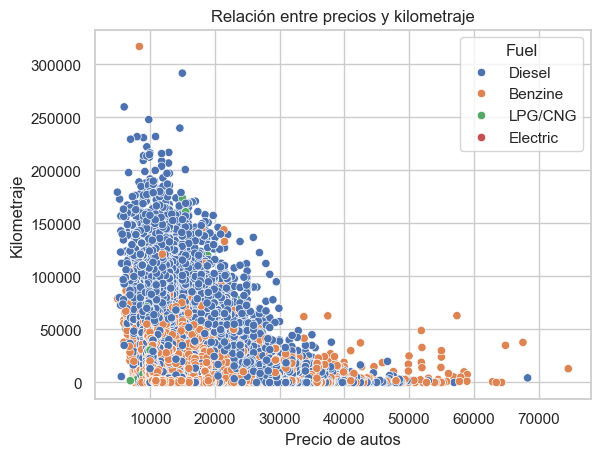

In [22]:
# Gráfico de dispersión: precio vs km
sns.scatterplot(x='price', y='km', hue='Fuel', data=df)
plt.title("Relación entre precios y kilometraje")
plt.xlabel("Precio de autos")
plt.ylabel("Kilometraje")
plt.show()

### <span style="color:black;"><strong>Interpretación</strong></span>

- Podemos observar un mayor valor en los autos con menos kilometraje y de tipo de combustible gasolina

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:18px">
<b>Análisis de correlación</b><br>
</div>

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>Coeficiente de correlación de Pearson</b><br>
</div>

Mide la fuerza y dirección de la relación lineal entre dos variables cuantitativas.


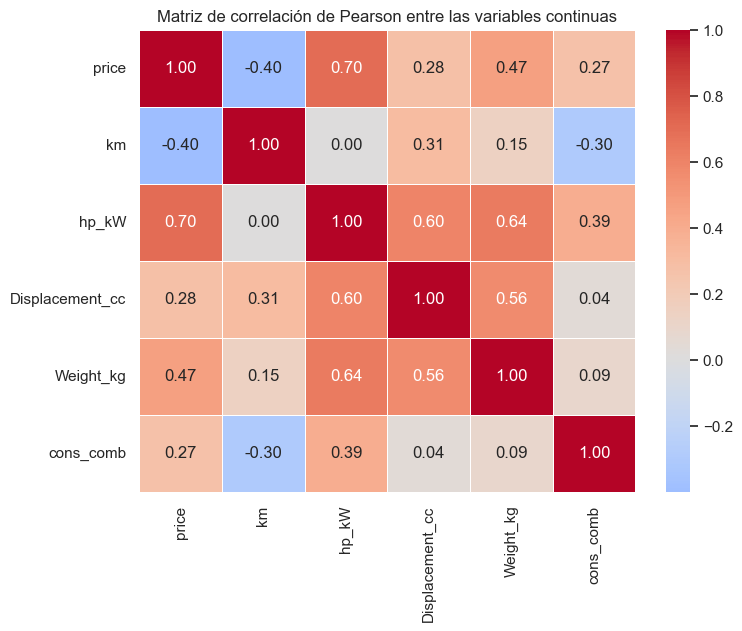

In [23]:
# Filtramos el DataFrame solo con esas variables
df_continuas = df[variables_continuas].dropna()

# Calculamos la matriz de correlaciones de Pearson
correlaciones = df_continuas.corr(method='pearson')

# Gráfico de mapa de calor
plt.figure(figsize=(8,6))
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Matriz de correlación de Pearson entre las variables continuas")
plt.show()

### <span style="color:black;"><strong>Interpretación</strong></span>

Interpretación de la matriz:

1.	price (precio)
- Fuerte correlación con hp_kW (0.70): Autos con más potencia suelen ser más caros.
- Correlación media con Weight_kg (0.47): Los autos más pesados tienden a tener mayor precio.
- Correlación baja con Displacement_cc (0.28): Cilindraje ayuda, pero no explica tanto como la potencia.

2.	km (kilometraje)
- Correlación negativa con price (-0.40): A más kilometraje, menor precio (esperado en autos usados).
- Correlación negativa con cons_comb (-0.30): Los autos con más km tienden a mostrar menor consumo combinado (posible sesgo por modelos más antiguos).
  
3.	hp_kW (caballos de fuerza en kW)
- Muy fuerte con Displacement_cc (0.60): A mayor cilindraje, más potencia.
- Fuerte con Weight_kg (0.64): Autos más pesados requieren motores más potentes.

4.	Displacement_cc (cilindraje)
- Moderada con Weight_kg (0.56): Autos más grandes suelen tener motores de mayor cilindraje.

5.	Weight_kg (peso)
- Se asocia moderadamente con price (0.47), hp_kW (0.64) y Displacement_cc (0.56): Autos más pesados tienen más potentes, son más grandes y más caros.

6.	cons_comb (consumo de combustible)
- Débil relación con casi todas, excepto hp_kW (0.39):Los autos con más caballos de fuerza tienden a gastar más combustible.

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>Relación de las variables con el Precio</b><br>
</div>

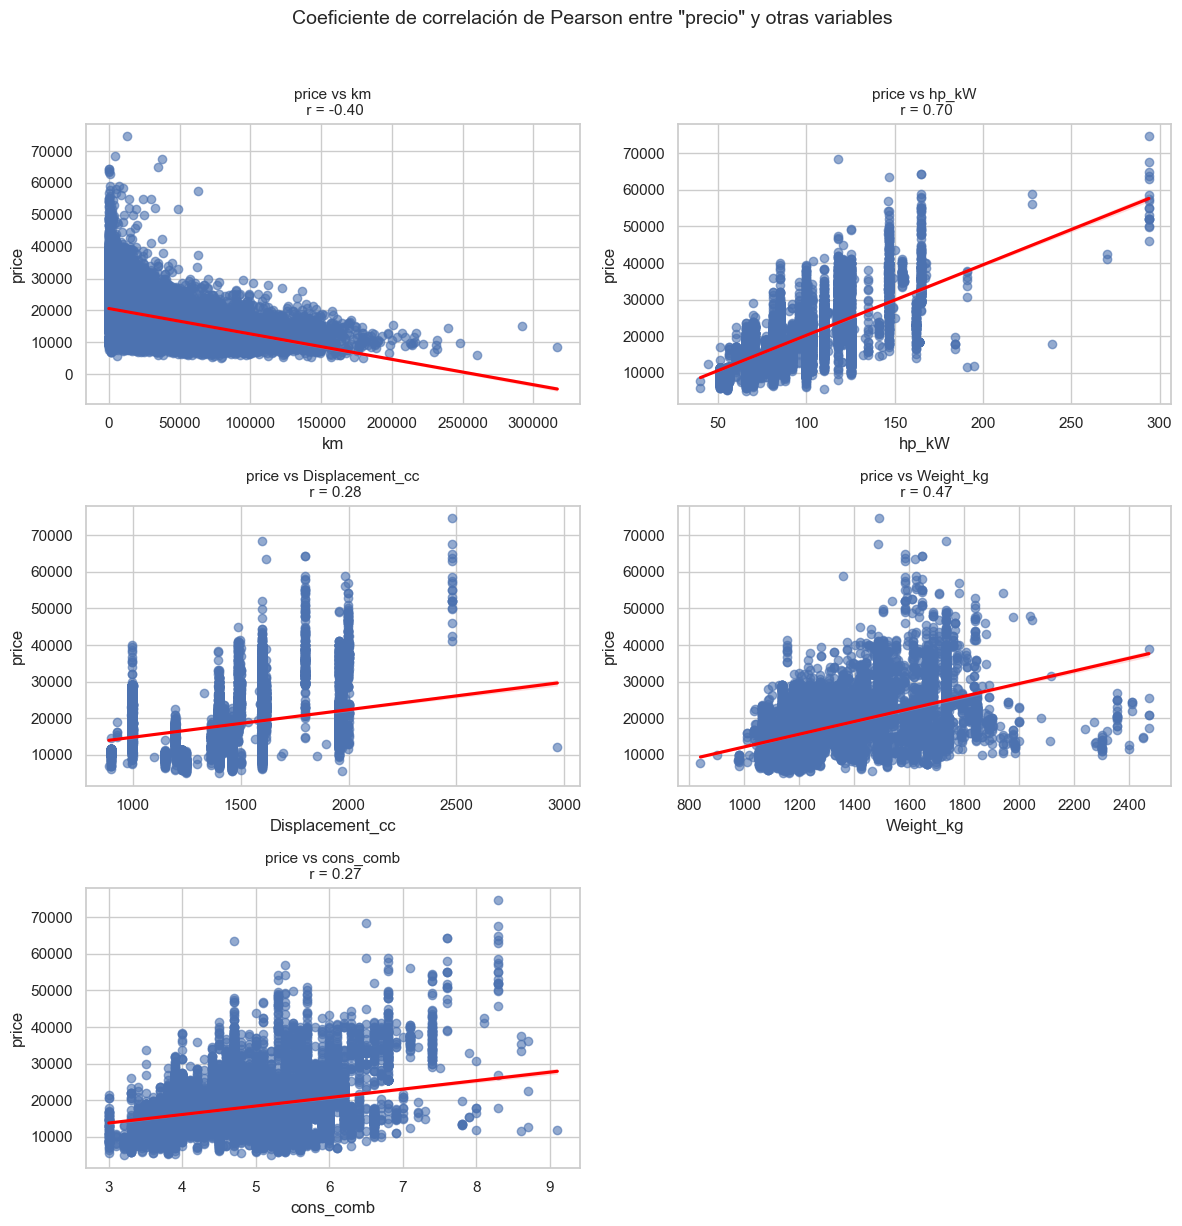

In [24]:
# Variables
variables = ['km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']  
target = 'price'

# Crear figura con 5 subgráficas (2 columnas)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

# Iterar sobre las variables
for i, var in enumerate(variables):
    x = df[var]
    y = df[target]
    
    # Calcular correlación de Pearson
    r, _ = pearsonr(x, y)
    
    # Gráfico de dispersión con línea de regresión
    sns.regplot(x=x, y=y, ax=axes[i], scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    
    # Título con valor de r
    axes[i].set_title(f'{target} vs {var}\n r = {r:.2f}', fontsize=11)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel(target)

# Eliminar subgráficas vacías si hay menos de 6
for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Coeficiente de correlación de Pearson entre "precio" y otras variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### <span style="color:black;"><strong>Interpretación</strong></span>

El análisis de correlación de Pearson entre la variable dependiente price y las variables explicativas continuas revela los siguientes valores: 

<p style="text-align:center;">
  <img src="imgs/tabla3.jpg" alt="bannersp" style="width:40%; border-radius:10px;">
</p>

En primer lugar, la variable kilometraje (km) presenta una correlación negativa moderada (r = -0.40), lo que indica que, a medida que aumenta el kilometraje recorrido, el precio del vehículo tiende a disminuir. Este resultado es consistente con la depreciación natural asociada al uso del automóvil.

Por otro lado, la potencia del motor (hp_kW) muestra una correlación positiva fuerte (r = 0.70), evidenciando que los vehículos con mayor potencia suelen tener precios más elevados, lo cual es coherente con la relación esperada entre rendimiento y valor comercial. Asimismo, variables como la cilindraje (Displacement_cc) (r = 0.28) y el peso del vehículo (Weight_kg) (r = 0.47) presentan correlaciones positivas débiles a moderadas, lo que sugiere que, aunque los autos más grandes o pesados tienden a tener precios superiores, la relación no es tan determinante como la potencia. Finalmente, el consumo de combustible (cons_comb) muestra una correlación positiva débil (r = 0.27), posiblemente asociada al hecho de que los motores más potentes y de mayor cilindrada suelen tener mayor consumo.

En conjunto, los resultados indican que la potencia del motor constituye el factor más influyente sobre el precio, mientras que el kilometraje actúa en sentido opuesto, reduciendo significativamente el valor del vehículo. Las demás variables contribuyen en menor medida a explicar la variación del precio en el mercado analizado.

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:18px">
<b>Chi-cuadrado de independencia</b><br>
</div>


🔹 Relación entre Gears y age
Chi² = 168.835, p-valor = 0.00000, dof = 9
Asociación significativa


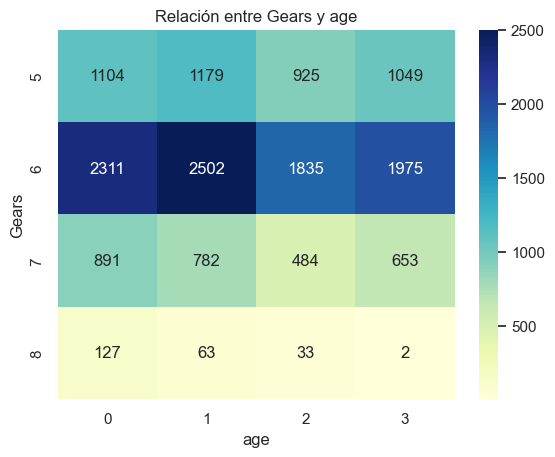


🔹 Relación entre Gears y Previous_Owners
Chi² = 87.937, p-valor = 0.00000, dof = 12
Asociación significativa


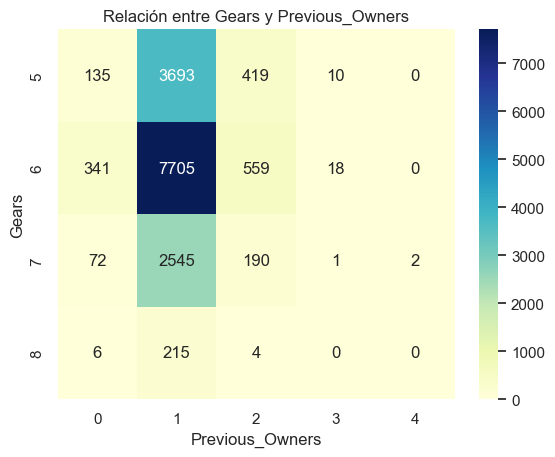


🔹 Relación entre Gears y Inspection_new
Chi² = 128.754, p-valor = 0.00000, dof = 3
Asociación significativa


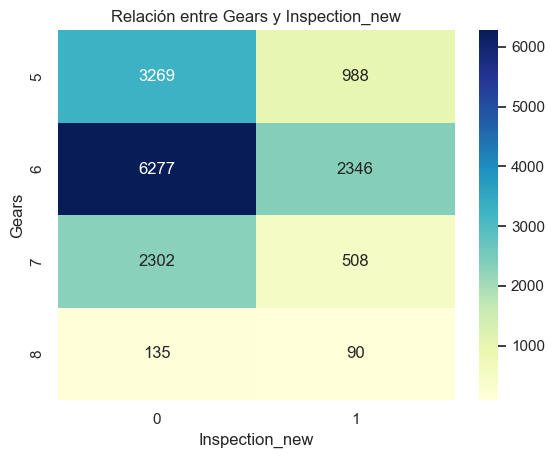


🔹 Relación entre age y Previous_Owners
Chi² = 2240.179, p-valor = 0.00000, dof = 12
Asociación significativa


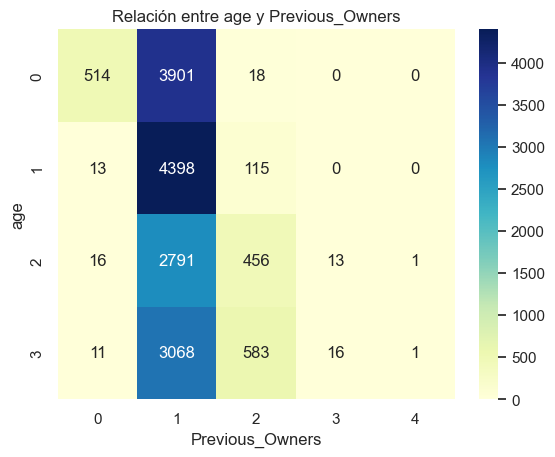


🔹 Relación entre age y Inspection_new
Chi² = 107.881, p-valor = 0.00000, dof = 3
Asociación significativa


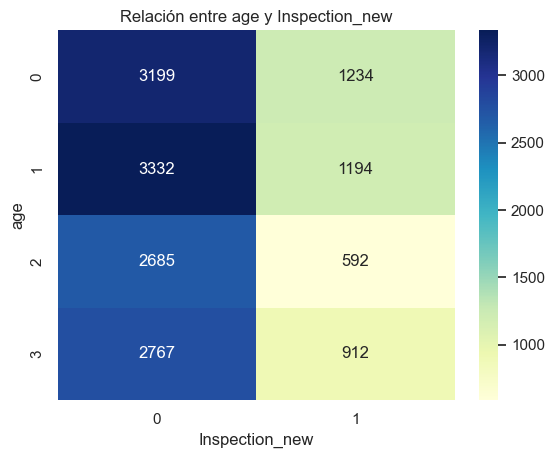


🔹 Relación entre Previous_Owners y Inspection_new
Chi² = 17.219, p-valor = 0.00175, dof = 4
Asociación significativa


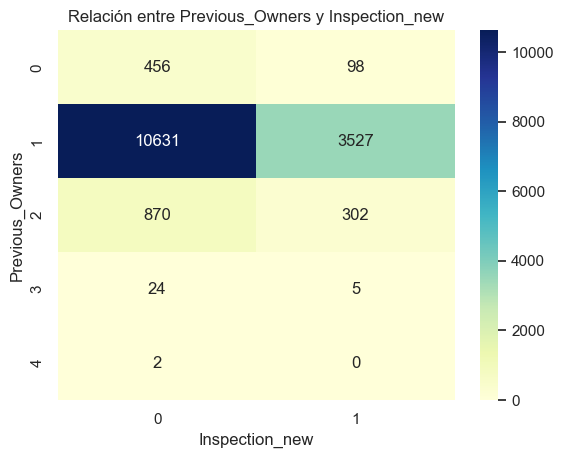

In [25]:
from itertools import combinations

variables_discretas = ['Gears', 'age', 'Previous_Owners', 'Inspection_new']

for var1, var2 in combinations(variables_discretas, 2):
    print(f"\n🔹 Relación entre {var1} y {var2}")
    tabla = pd.crosstab(df[var1], df[var2])
    
    chi2, p, dof, expected = chi2_contingency(tabla)
    print(f"Chi² = {chi2:.3f}, p-valor = {p:.5f}, dof = {dof}")
    
    if p < 0.05:
        print("Asociación significativa")
    else:
        print("No hay asociación significativa")
    
    sns.heatmap(tabla, annot=True, cmap="YlGnBu", fmt="d")
    plt.title(f"Relación entre {var1} y {var2}")
    plt.xlabel(var2)
    plt.ylabel(var1)
    plt.show()



### <span style="color:black;"><strong>Interpretación</strong></span>

Todas las variables discretas están estrechamente relacionadas entre sí.
Esto indica que la edad del vehículo y su número de dueños influyen en sus características de transmisión y estado de inspección, lo que refleja patrones consistentes en el mercado automotriz.

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:20px">
<b>Análisis multivariado</b><br>
</div>

Las variables se analizan mediante:
- Análisis de Componentes Principales (ACP / PCA)
- Regresión Múltiple
- Análisis de Clúster (Cluster Analysis)
- Análisis Factorial

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:18px">
<b>Análisis de Componentes Principales (PCA)</b><br>
</div>

Varianza explicada por componente (%):
PC1: 45.64%
PC2: 26.53%
PC3: 12.79%
PC4: 6.80%
PC5: 5.82%
PC6: 2.42%


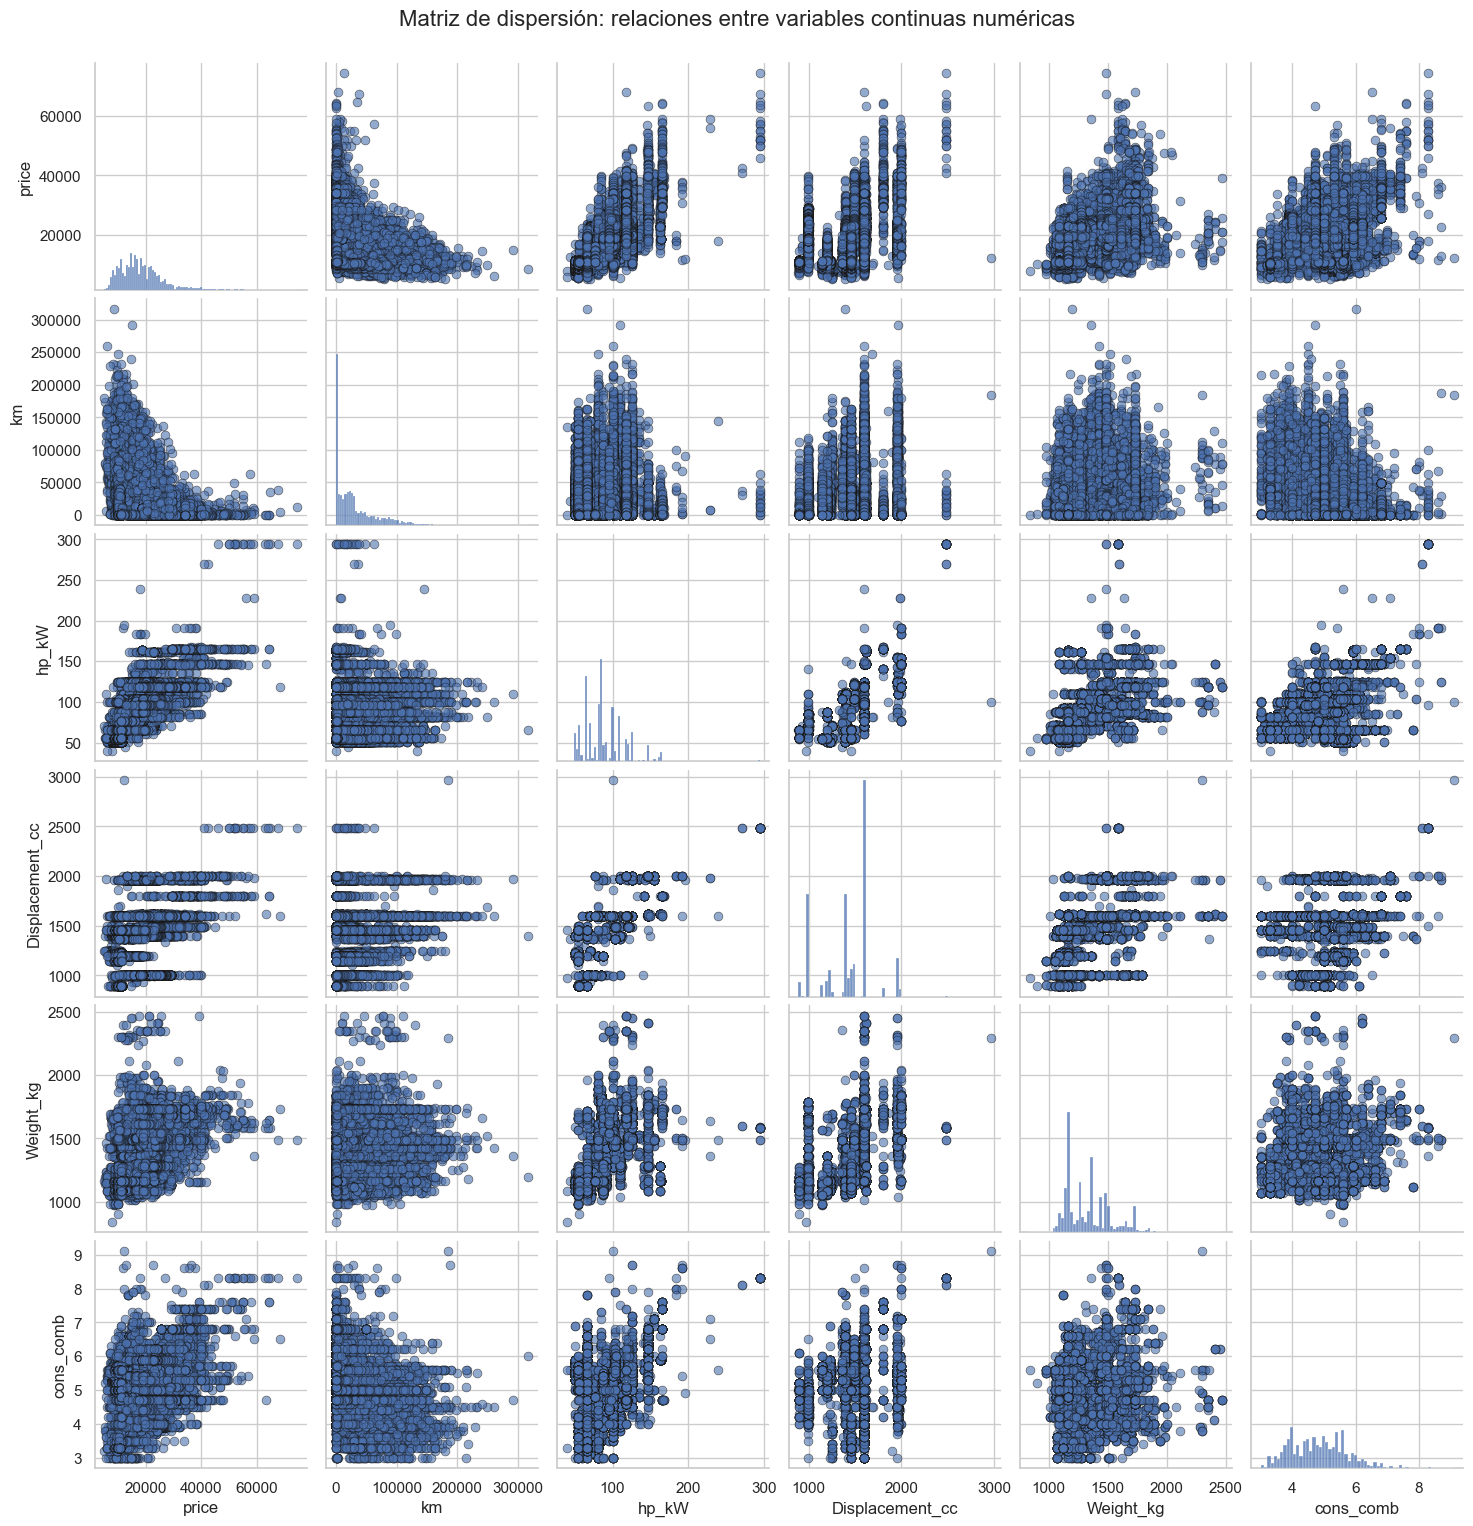

In [26]:
# Estandarizar variables
scaler = StandardScaler()
X_std = scaler.fit_transform(df[variables_continuas])

# PCA (Análisis de Componentes Principales)
pca = PCA()
X_pca = pca.fit_transform(X_std)

# Crear DataFrame con los componentes principales
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

# Mostrar varianza explicada por cada componente
varianza_explicada = pca.explained_variance_ratio_ * 100
print("Varianza explicada por componente (%):")
for i, var in enumerate(varianza_explicada):
    print(f"PC{i+1}: {var:.2f}%")

# Matriz de dispersión con tus variables originales
sns.pairplot(df[variables_continuas], diag_kind='hist', corner=False,
             plot_kws={'alpha':0.6, 's':40, 'edgecolor':'k'})
plt.suptitle('Matriz de dispersión: relaciones entre variables continuas numéricas', fontsize=16, y=1.02)
plt.show()


### <span style="color:black;"><strong>Interpretación</strong></span>

PC1 (45.64%): El primer componente principal explica casi la mitad de la variabilidad total del conjunto de datos, lo que sugiere que existe una combinación lineal de variables que resume gran parte de la información original.

PC2 (26.53%): El segundo componente añade un 26.53% adicional, lo que eleva la varianza acumulada a 72.17%. Con los dos primeros componentes se explica más del 70% de la variabilidad total, lo cual es un resultado muy bueno en análisis multivariado.

PC3 (12.79%): Con el tercer componente se alcanza aproximadamente 85% de la varianza total explicada, lo que indica que las tres primeras componentes contienen prácticamente toda la estructura informativa relevante.

PC4 a PC6 (menores al 7%): Los últimos componentes aportan una cantidad pequeña de varianza, por lo que pueden considerarse menos relevantes o incluso prescindibles si el objetivo es simplificar el modelo.

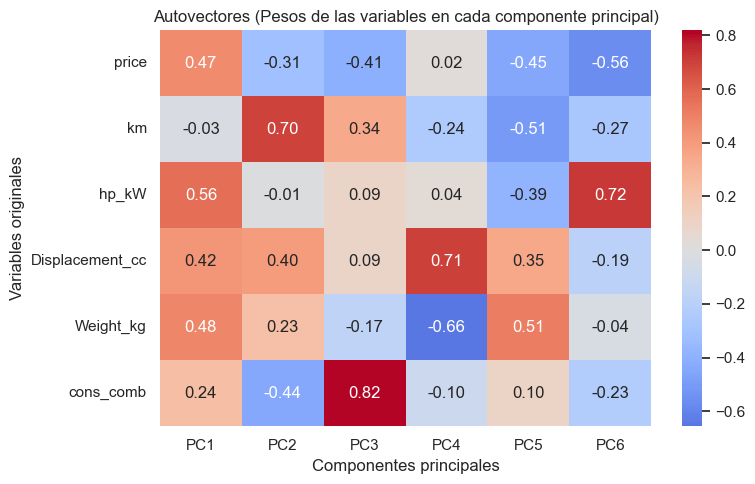

Ecuaciones de los componentes principales:

PC1 = 0.467·'price' + -0.032·'km' + 0.562·'hp_kW' + 0.423·'Displacement_cc' + 0.479·'Weight_kg' + 0.238·'cons_comb'
PC2 = -0.314·'price' + 0.701·'km' + -0.007·'hp_kW' + 0.398·'Displacement_cc' + 0.23·'Weight_kg' + -0.445·'cons_comb'
PC3 = -0.41·'price' + 0.342·'km' + 0.092·'hp_kW' + 0.088·'Displacement_cc' + -0.17·'Weight_kg' + 0.818·'cons_comb'
PC4 = 0.022·'price' + -0.242·'km' + 0.039·'hp_kW' + 0.706·'Displacement_cc' + -0.655·'Weight_kg' + -0.105·'cons_comb'
PC5 = -0.45·'price' + -0.507·'km' + -0.39·'hp_kW' + 0.347·'Displacement_cc' + 0.508·'Weight_kg' + 0.098·'cons_comb'
PC6 = -0.558·'price' + -0.273·'km' + 0.723·'hp_kW' + -0.187·'Displacement_cc' + -0.039·'Weight_kg' + -0.234·'cons_comb'


In [27]:
# Matriz de componentes (autovectores)
componentes = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(variables_continuas))],
    index=variables_continuas
)

# Visualización de autovectores
plt.figure(figsize=(8, 5))
sns.heatmap(componentes, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Autovectores (Pesos de las variables en cada componente principal)')
plt.ylabel('Variables originales')
plt.xlabel('Componentes principales')
plt.tight_layout()
plt.show()

# Ecuaciones de los componentes principales
print("Ecuaciones de los componentes principales:\n")
for i, comp in enumerate(componentes.columns):
    pesos = pca.components_[i]
    ecuacion = " + ".join([f"{round(pesos[j], 3)}·'{variables_continuas[j]}'" for j in range(len(pesos))])
    print(f"{comp} = {ecuacion}")


### <span style="color:black;"><strong>Interpretación</strong></span>

Las ecuaciones de los componentes principales muestran qué tanto contribuye cada variable original a cada componente (autovector).
El signo (positivo o negativo) indica el sentido de la relación, y el valor absoluto indica la fuerza de la contribución.

Los dos principales componentes explican:

- PC1 = 0.467 * price − 0.032 * km + 0.562 * hp_kW + 0.423 * Displacement_cc + 0.479 * Weight_kg + 0.238 * cons_comb

Este componente está dominado por las variables hp_kW, Weight_kg, price y Displacement_cc, todas con coeficientes positivos altos.Representa una dimensión de potencia y tamaño del vehículo.Cuanto mayor sea el valor del PC1, mayor es el rendimiento del vehículo (más caballos de fuerza, más peso y mayor cilindraje).

- PC2 = −0.314 * price + 0.701 * km − 0.007*hp_kW + 0.398 * Displacement_cc + 0.230 * Weight_kg − 0.445 * cons_comb

Aquí destaca km (kilometraje) con un peso positivo alto (0.701) y cons_comb (consumo) con un peso negativo (−0.445).
Este componente parece medir una dimensión de uso y eficiencia: vehículos con alto kilometraje y bajo consumo de combustible.


Tabla de varianza explicada:

  Componente  Autovalor    PVE  PVE acumulada
0        PC1      2.739  0.456          0.456
1        PC2      1.592  0.265          0.722
2        PC3      0.767  0.128          0.850
3        PC4      0.408  0.068          0.918
4        PC5      0.349  0.058          0.976
5        PC6      0.145  0.024          1.000


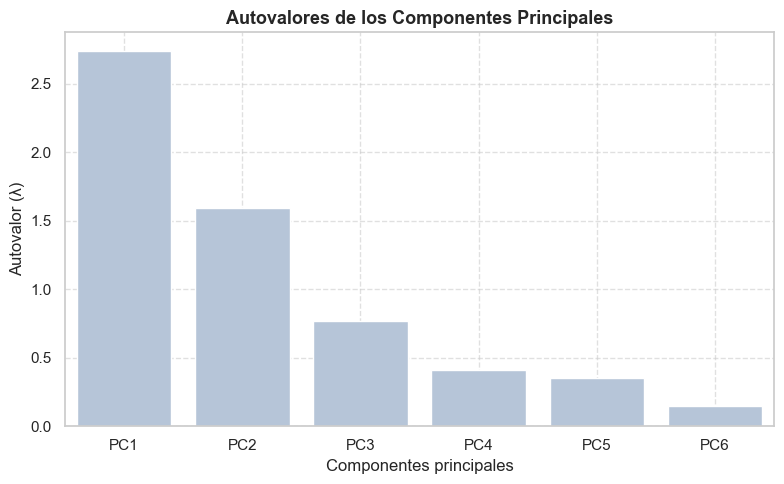

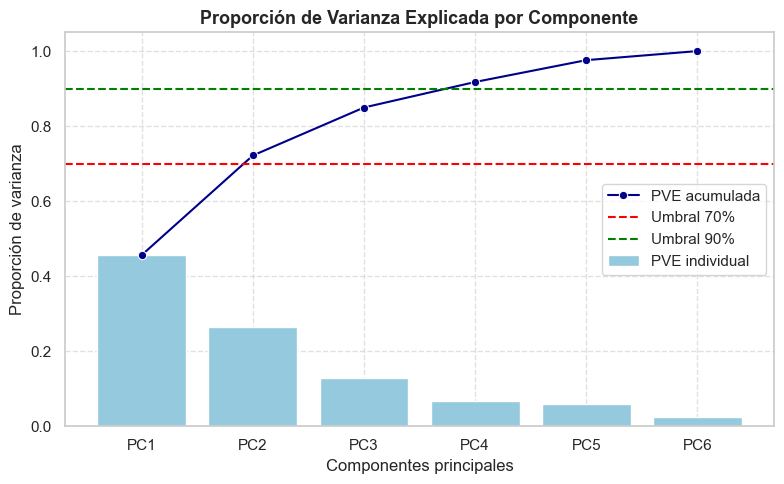

In [28]:
# Autovalores y proporción de varianza explicada
varianza = pca.explained_variance_
PVE = pca.explained_variance_ratio_
PVE_acum = np.cumsum(PVE)
componentes = [f'PC{i+1}' for i in range(len(PVE))]

# Crear DataFrame
df_varianza = pd.DataFrame({
    'Componente': componentes,
    'Autovalor': varianza,
    'PVE': PVE,
    'PVE acumulada': PVE_acum
})

# Mostrar tabla con resultados
print("Tabla de varianza explicada:\n")
print(df_varianza.round(3))


# Gráfico de Autovalores
plt.figure(figsize=(8, 5))
sns.barplot(x='Componente', y='Autovalor', data=df_varianza, color='lightsteelblue')
plt.title('Autovalores de los Componentes Principales', fontsize=13, weight='bold')
plt.ylabel('Autovalor (λ)')
plt.xlabel('Componentes principales')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Gráfico de PVE y PVE Acumulada
plt.figure(figsize=(8, 5))
sns.barplot(x='Componente', y='PVE', data=df_varianza, color='skyblue', label='PVE individual')
sns.lineplot(x='Componente', y='PVE acumulada', data=df_varianza, marker='o', color='darkblue', label='PVE acumulada')
plt.axhline(0.7, color='red', linestyle='--', label='Umbral 70%')
plt.axhline(0.9, color='green', linestyle='--', label='Umbral 90%')
plt.title('Proporción de Varianza Explicada por Componente', fontsize=13, weight='bold')
plt.ylabel('Proporción de varianza')
plt.xlabel('Componentes principales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### <span style="color:black;"><strong>Interpretación</strong></span>
Al analizar la gráfica de varianza explicada acumulada, se observa que los dos primeros componentes principales (PC1 y PC2) concentran más del 70% de la variabilidad total de los datos, lo que indica que gran parte de la información contenida en las variables originales puede resumirse adecuadamente en un plano bidimensional.
Asimismo, al incorporar el tercer componente (PC3), la varianza acumulada supera el 80%, reforzando que los tres primeros componentes capturan la mayoría de la estructura subyacente del conjunto de datos, reduciendo significativamente la dimensionalidad sin una pérdida importante de información.

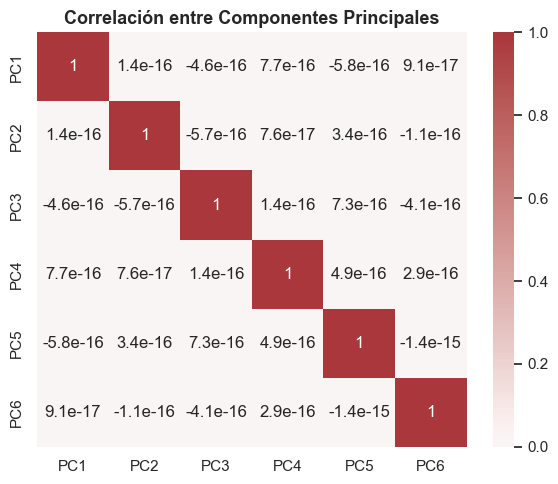

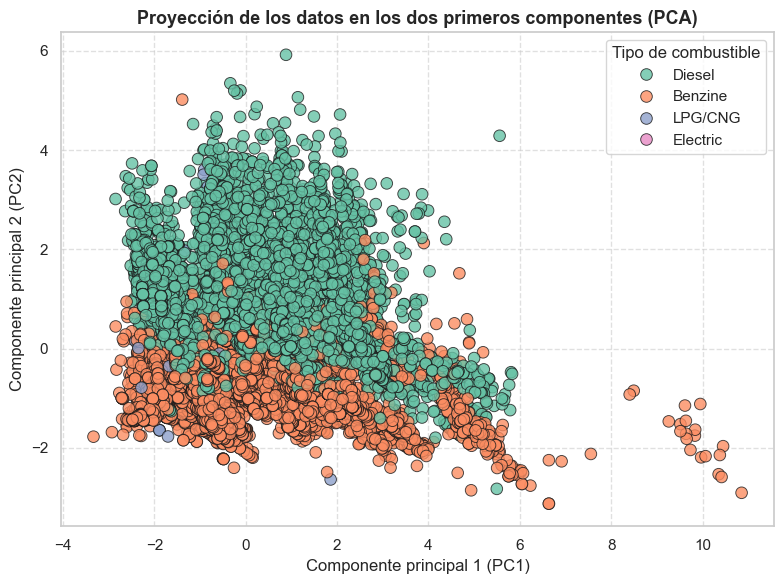

In [29]:
# Correlación entre componentes PCA

df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(len(PVE))])
correlaciones = df_pca.corr()


plt.figure(figsize=(6, 5))
sns.heatmap(correlaciones, annot=True, cmap='vlag', center=0)
plt.title('Correlación entre Componentes Principales', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()


# Proyección en los dos primeros componentes
# Se Agrega una variable categórica (Fuel)
df_pca['Fuel'] = df['Fuel']

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x='PC1', y='PC2',
    hue='Fuel',  # variable categórica
    palette='Set2',
    alpha=0.8,
    s=70,
    edgecolor='k'
)
plt.title('Proyección de los datos en los dos primeros componentes (PCA)', fontsize=13, weight='bold')
plt.xlabel('Componente principal 1 (PC1)')
plt.ylabel('Componente principal 2 (PC2)')
plt.legend(title='Tipo de combustible', loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### <span style="color:Black;"><strong>Interpretación</strong></span>

La matriz de correlaciones entre los componentes principales muestra que todas las correlaciones fuera de la diagonal son prácticamente nulas (valores cercanos a cero). Esto indica que los componentes principales son mutuamente independientes y ortogonales, cumpliendo con la propiedad fundamental del PCA de generar nuevas variables no correlacionadas. Por tanto, cada componente explica una porción distinta y no redundante de la variabilidad total del conjunto de datos.

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:18px">
<b>Regresión Lineal Múltiple</b><br>
</div>

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>Supuestos del modelo</b><br>
</div>

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>1. Linealidad</b><br>
</div>

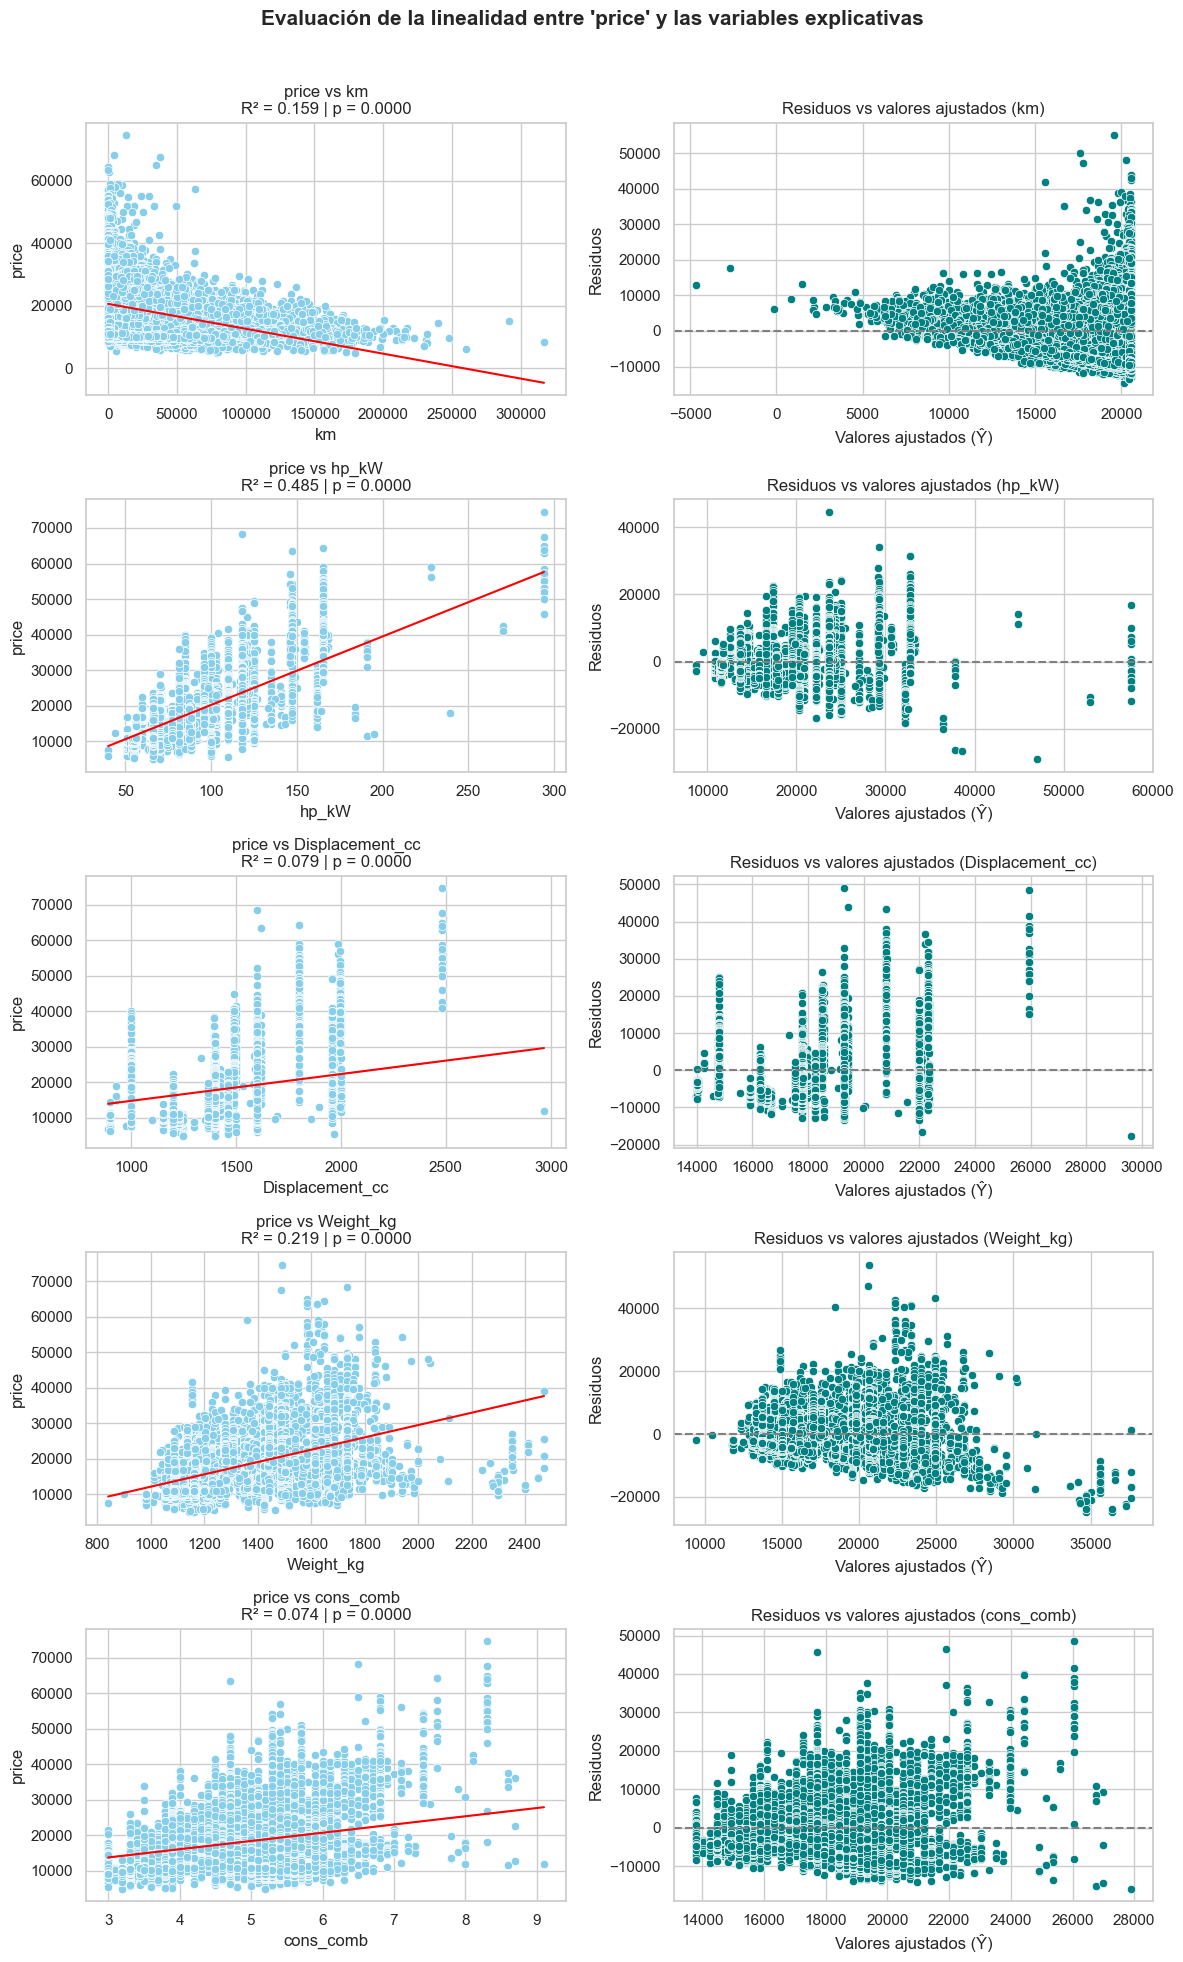

In [30]:
# Variables
target = 'price'
predictoras = [ 'km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']

# Configuración general de visualización
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(len(predictoras), 2, figsize=(12, 4*len(predictoras)))
fig.subplots_adjust(wspace=0.3, hspace=0.4)

# Iterar sobre cada variable predictora
for i, var in enumerate(predictoras):
    X = sm.add_constant(df[var])  # Agregar constante
    y = df[target]

    # Ajustar modelo lineal simple
    modelo = sm.OLS(y, X).fit()

    # (1) Dispersión + ajuste
    sns.scatterplot(x=df[var], y=y, color='skyblue', ax=axes[i, 0])
    sns.lineplot(x=df[var], y=modelo.fittedvalues, color='red', ax=axes[i, 0])
    axes[i, 0].set_title(f"{target} vs {var}\nR² = {modelo.rsquared:.3f} | p = {modelo.pvalues[var]:.4f}")
    axes[i, 0].set_xlabel(var)
    axes[i, 0].set_ylabel(target)

    # (2) Residuos
    sns.scatterplot(x=modelo.fittedvalues, y=modelo.resid, color='teal', ax=axes[i, 1])
    axes[i, 1].axhline(0, color='gray', linestyle='--')
    axes[i, 1].set_title(f"Residuos vs valores ajustados ({var})")
    axes[i, 1].set_xlabel("Valores ajustados (Ŷ)")
    axes[i, 1].set_ylabel("Residuos")

plt.suptitle("Evaluación de la linealidad entre 'price' y las variables explicativas", fontsize=15, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


### <span style="color:Black;"><strong>Interpretación</strong></span>

Algunas relaciones podrían no ser puramente lineales, es necesario realizar transformaciones logarítmicas, para cumplir con este supuesto.

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>2. Independencia</b><br>
</div>

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.677
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     6657.
Date:                Wed, 26 Nov 2025   Prob (F-statistic):               0.00
Time:                        17:21:01   Log-Likelihood:            -1.5535e+05
No. Observations:               15915   AIC:                         3.107e+05
Df Residuals:                   15909   BIC:                         3.108e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            5916.5637    331.573     

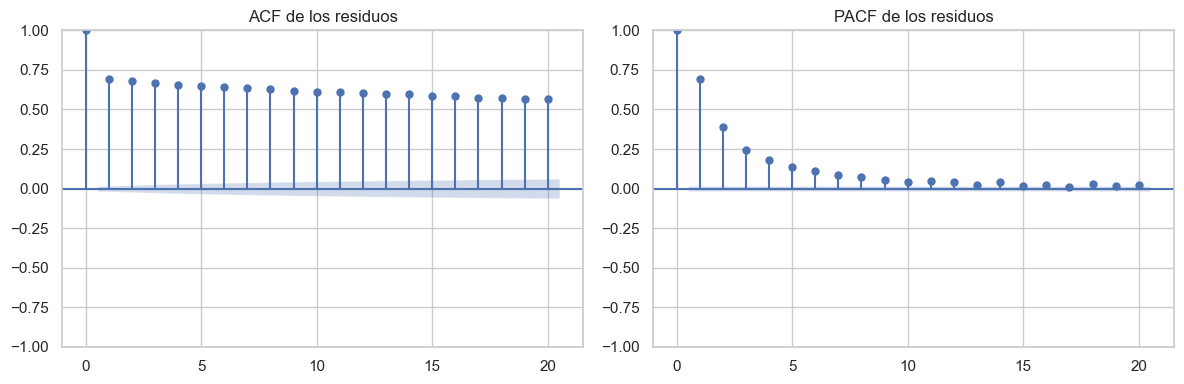

In [31]:
# Variable dependiente y explicativas
y = df['price']
X = df[['km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']]

# Modelo de regresión lineal múltiple
X_const = sm.add_constant(X)  #Agregar constante para el intercepto
model = sm.OLS(y, X_const).fit()  # Ajustar modelo

# resultados
print(model.summary())

# Residusos
resid = model.resid

# Prueba de DURBIN-WATSON
dw = durbin_watson(resid)
print(f"\nDurbin-Watson: {dw:.3f}")
if dw < 1.5:
    print("Posible autocorrelación positiva de los residuos.")
elif dw > 2.5:
    print("Posible autocorrelación negativa de los residuos.")
else:
    print("No hay evidencia fuerte de autocorrelación.")

# Gráficos ACF y PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(resid, ax=axes[0], lags=20)
axes[0].set_title("ACF de los residuos")
plot_pacf(resid, ax=axes[1], lags=20)
axes[1].set_title("PACF de los residuos")
plt.tight_layout()
plt.show()


### <span style="color:Black;"><strong>Interpretación</strong></span>

Con DW = 0.617, hay autocorrelación positiva fuerte. Esto significa:

- Los residuos consecutivos están correlacionados.
- El supuesto de independencia NO se cumple.
- Los errores en observaciones cercanas tienden a ser similares.

Análisis ACF/PACF

ACF (Función de Autocorrelación):

- Patrón observado: Decaimiento lento y gradual.
- Todos los rezagos iniciales significativamente altos.
Confirma autocorrelación persistente en múltiples rezagos.

PACF (Función de Autocorrelación Parcial):

- Patrón observado: Primer rezago muy alto (~0.7).
- Caída abrupta después del lag 1.
- Rezagos posteriores dentro de bandas de confianza.

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>3. Homoscedasticidad</b><br>
</div>

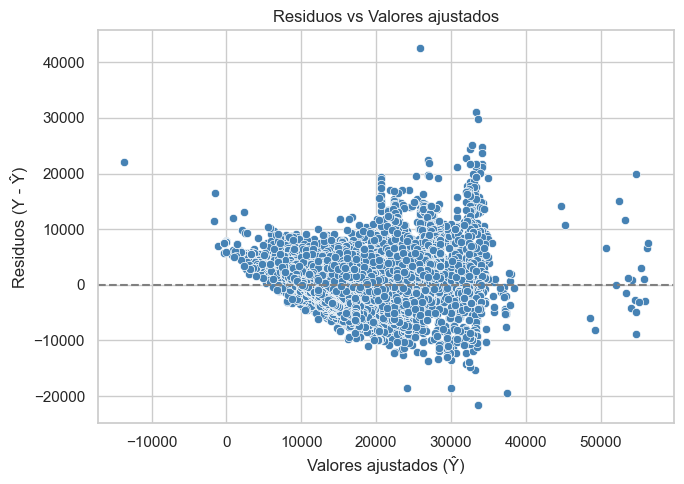

Prueba de Breusch–Pagan:
LM Statistic: 1568.099
p-valor: 0.0000
Posible heterocedasticidad (varianza de los errores no constante).


In [32]:
# Residuos y valores ajustados
resid = model.resid
fitted = model.fittedvalues

# Gráfico de residuos
plt.figure(figsize=(7, 5))
sns.scatterplot(x=fitted, y=resid, color='steelblue')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Residuos vs Valores ajustados")
plt.xlabel("Valores ajustados (Ŷ)")
plt.ylabel("Residuos (Y - Ŷ)")
plt.tight_layout()
plt.show()

# Prueba de BREUSCH–PAGAN
bp_test = het_breuschpagan(resid, X_const)
labels = ['LM Statistic', 'p-value', 'f-value', 'f p-value']
bp_results = dict(zip(labels, bp_test))

print("Prueba de Breusch–Pagan:")
print(f"LM Statistic: {bp_results['LM Statistic']:.3f}")
print(f"p-valor: {bp_results['p-value']:.4f}")

if bp_results['p-value'] > 0.05:
    print("No hay evidencia de heterocedasticidad (varianza constante de los errores).")
else:
    print("Posible heterocedasticidad (varianza de los errores no constante).")


### <span style="color:Black;"><strong>Interpretación</strong></span>

Se detecta heterocedasticidad, se recomienda ajustar el modelo utilizando errores robustos o aplicar transformaciones a la variable dependiente para estabilizar la varianza.


<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>4. Normalidad</b><br>
</div>

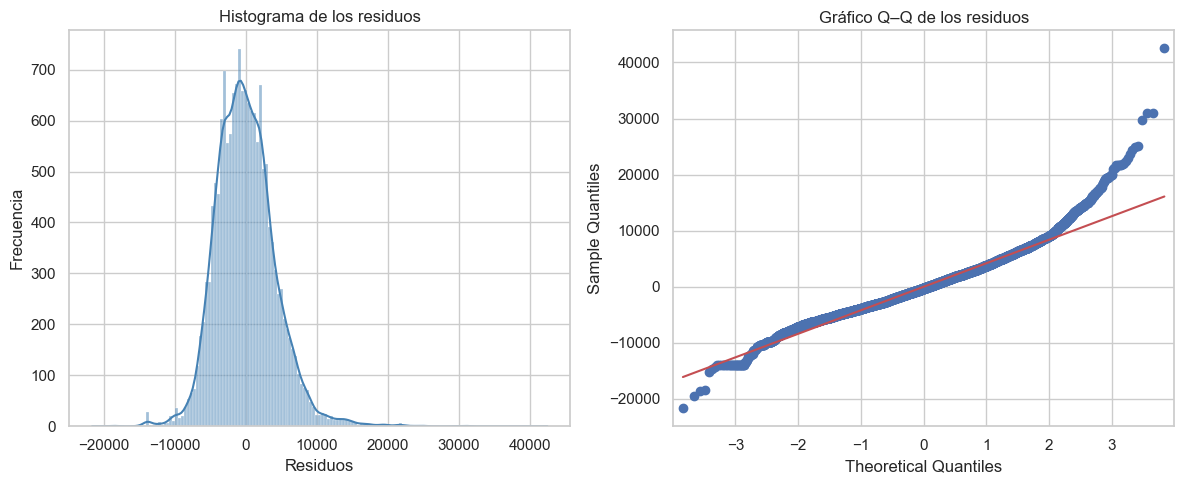

Prueba de Shapiro–Wilk:
Estadístico W = 0.9700
p-valor = 0.0000
→ No se cumple el supuesto de normalidad 


C:\Users\Nitro V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15915.
  res = hypotest_fun_out(*samples, **kwds)


In [33]:

# Visualizacíon de Normalidad
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma de residuos
sns.histplot(resid, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Histograma de los residuos")
axes[0].set_xlabel("Residuos")
axes[0].set_ylabel("Frecuencia")

# Gráfico Q–Q (Quantile-Quantile)
qqplot(resid, line='s', ax=axes[1])
axes[1].set_title("Gráfico Q–Q de los residuos")

plt.tight_layout()
plt.show()

# Prueba de Normalidad
stat, p_value = shapiro(resid)
print("Prueba de Shapiro–Wilk:")
print(f"Estadístico W = {stat:.4f}")
print(f"p-valor = {p_value:.4f}")

if p_value > 0.05:
    print("→ Se asume normalidad en los residuos ")
else:
    print("→ No se cumple el supuesto de normalidad ")

### <span style="color:Black;"><strong>Interpretación</strong></span>

No se cumple el supuesto de normalidad, se ve necesario realizar transformaciones de las variables originales

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:15px">
<b>5. Ausencia de multicolinealidad</b><br>
</div>

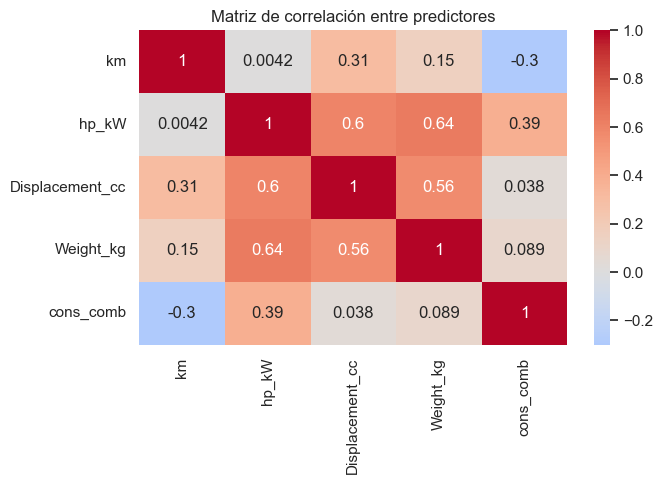

Factores de inflación de varianza (VIF):
          Variable        VIF
0            const  99.259946
1               km   1.252306
2            hp_kW   2.559685
3  Displacement_cc   1.962765
4        Weight_kg   1.900706
5        cons_comb   1.382357 

 Índice de condición: 490028.87

Interpretación:
- VIF ≈ 1: Sin colinealidad
- 1 < VIF < 5: Colinealidad moderada (aceptable)
- VIF ≥ 10: Problema serio de multicolinealidad 
- Índice de condición < 10: Bien 
- 10–30: Colinealidad moderada 
- > 30: Colinealidad severa 


In [34]:
# --- Variables predictoras ---
X = df[['km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']]

# Matriz de correlación
plt.figure(figsize=(7, 5))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Matriz de correlación entre predictores")
plt.tight_layout()
plt.show()

# Función para Calcular el VIF
def calcular_vif(X):
    X_const = sm.add_constant(X)
    vif = pd.DataFrame()
    vif["Variable"] = X_const.columns
    vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
    return vif

# Calcular el VIF
vif_df = calcular_vif(X)
print("Factores de inflación de varianza (VIF):")
print(vif_df, "\n")

# Índice de correlación
def calcular_indice_condicion(X):
    X_const = sm.add_constant(X)
    _, s, _ = svd(X_const)
    return max(s) / min(s)

indice_cond = calcular_indice_condicion(X)
print(f" Índice de condición: {indice_cond:.2f}")

# Interpretación
print("\nInterpretación:")
print("- VIF ≈ 1: Sin colinealidad")
print("- 1 < VIF < 5: Colinealidad moderada (aceptable)")
print("- VIF ≥ 10: Problema serio de multicolinealidad ")
print("- Índice de condición < 10: Bien ")
print("- 10–30: Colinealidad moderada ")
print("- > 30: Colinealidad severa ")


### <span style="color:Black;"><strong>Interpretación</strong></span>

Las variables predictoras NO tienen multicolinealidad problemática.
Todos los VIF son menos de 3, muy por debajo del umbral de 5, las variables son relativamente independientes entre sí.

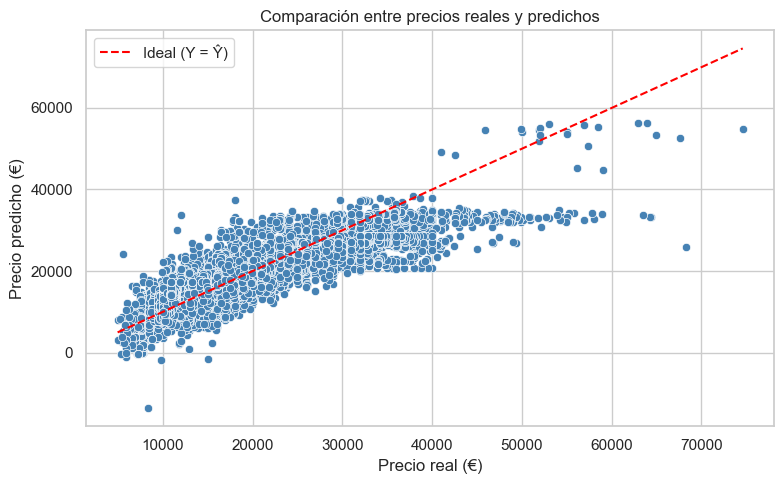

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.677
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     6657.
Date:                Wed, 26 Nov 2025   Prob (F-statistic):               0.00
Time:                        17:21:19   Log-Likelihood:            -1.5535e+05
No. Observations:               15915   AIC:                         3.107e+05
Df Residuals:                   15909   BIC:                         3.108e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            5916.5637    331.573     

In [35]:
# Variables predictoras y dependiente
X = df[['km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']]
Y = df['price']

# Agregar constante para el intercepto
X_const = sm.add_constant(X)

# Ajustar modelo de regresión lineal múltiple
modelo = sm.OLS(Y, X_const).fit()

# Predicciones
Y_pred = modelo.predict(X_const)

# Evaluación visual
plt.figure(figsize=(8, 5))
sns.scatterplot(x=Y, y=Y_pred, color='steelblue')
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], color='red', linestyle='--', label='Ideal (Y = Ŷ)')
plt.xlabel('Precio real (€)')
plt.ylabel('Precio predicho (€)')
plt.title('Comparación entre precios reales y predichos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Resultados del modelo
print(modelo.summary())


<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:18px">
<b>Análisis de clúster</b><br>
</div>

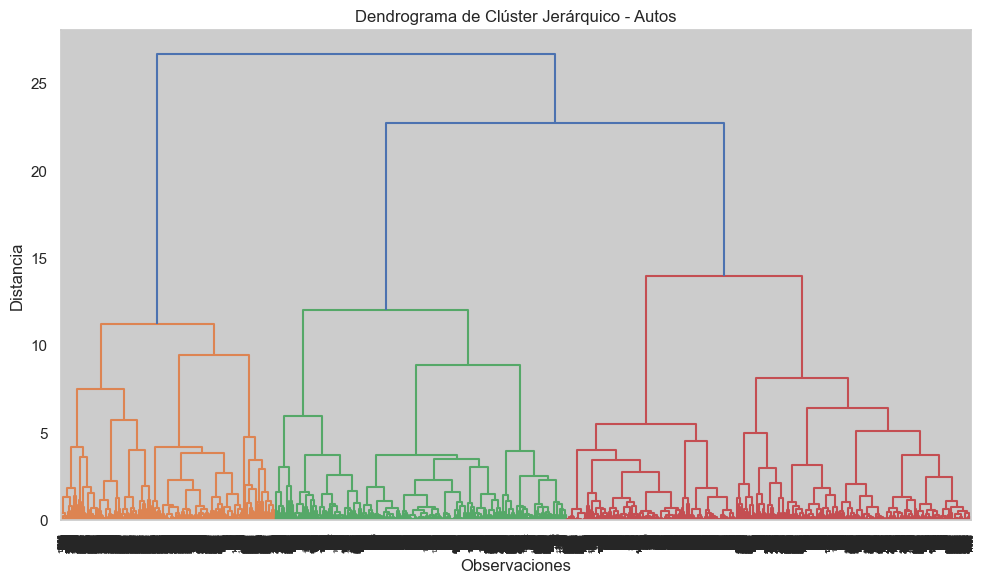

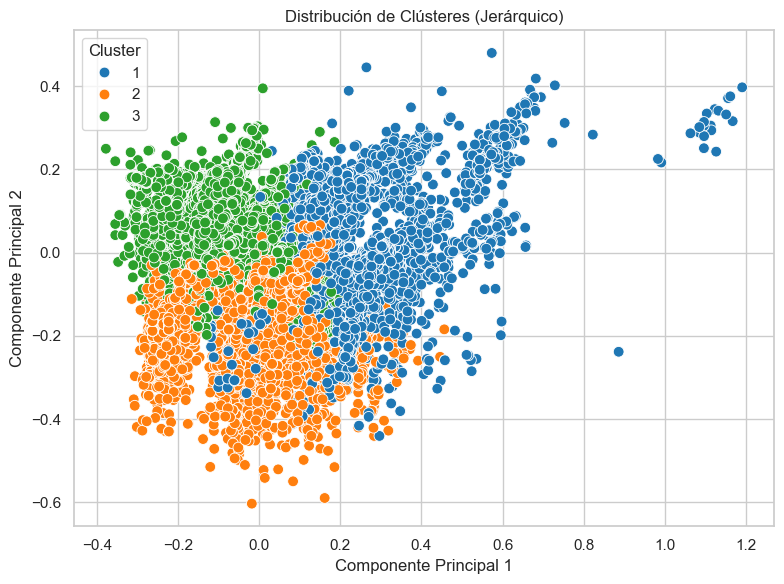

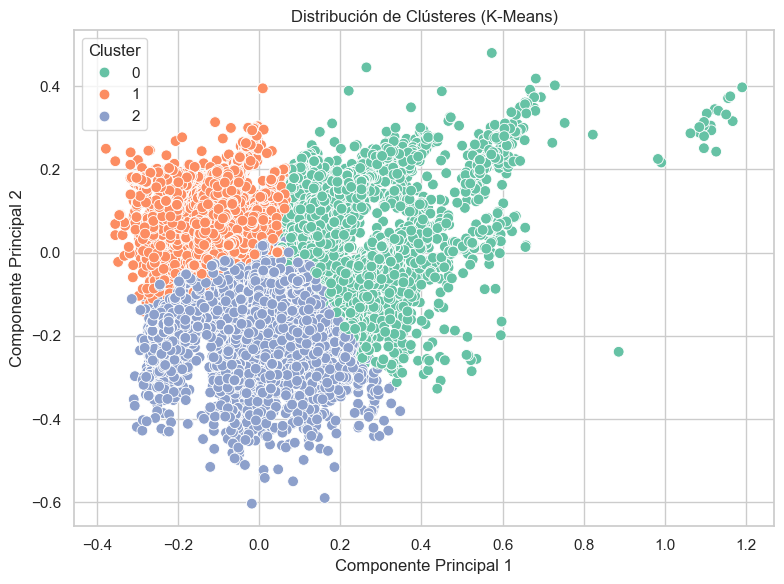

=== Promedios por clúster (K-Means) ===
                   price        km   hp_kW  Displacement_cc  Weight_kg  \
Cluster_KMeans                                                           
0               25657.18  22735.41  123.34          1652.03    1539.25   
1               15326.82  17008.90   71.48          1172.77    1194.92   
2               15994.84  55804.13   84.68          1573.55    1366.71   

                cons_comb  Cluster_Jerarquico   PC1   PC2  
Cluster_KMeans                                             
0                    5.62                1.19  0.27  0.06  
1                    5.08                2.98 -0.14  0.11  
2                    4.01                2.00 -0.02 -0.17  


In [36]:
# Análisis de clúster

# variables continuas 
continuas = df[['price', 'km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']].dropna()

#  Escalamiento 
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(continuas)

# Clúster jerárquico
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title('Dendrograma de Clúster Jerárquico - Autos')
plt.xlabel('Observaciones')
plt.ylabel('Distancia')
plt.tight_layout()
plt.show()

# Número de clústeres ( 3)
n_clusters = 3
grupos_h = fcluster(Z, t=n_clusters, criterion='maxclust')
continuas['Cluster_Jerarquico'] = grupos_h

# Visualización 2D con PCA
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)
continuas['PC1'] = componentes[:,0]
continuas['PC2'] = componentes[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=continuas, x='PC1', y='PC2', hue='Cluster_Jerarquico', palette='tab10', s=60)
plt.title('Distribución de Clústeres (Jerárquico)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# Clúster no jerárquico (K-Means)
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
continuas['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(data=continuas, x='PC1', y='PC2', hue='Cluster_KMeans', palette='Set2', s=60)
plt.title('Distribución de Clústeres (K-Means)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# Comparar promedios por grupo 
resumen = continuas.groupby('Cluster_KMeans').mean().round(2)
print("=== Promedios por clúster (K-Means) ===")
print(resumen)


Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 17367.0
=== Frecuencia de autos por clúster (K-Modes) ===
Cluster_KModes
0    10881
1     2965
2     2069
Name: count, dtype: int64

=== Categorías predominantes por clúster ===
               Gears age Previous_Owners Inspection_new
Cluster_KModes                                         
0                  6   1               1              0
1                  5   0               1              1
2                  5   3               1              0


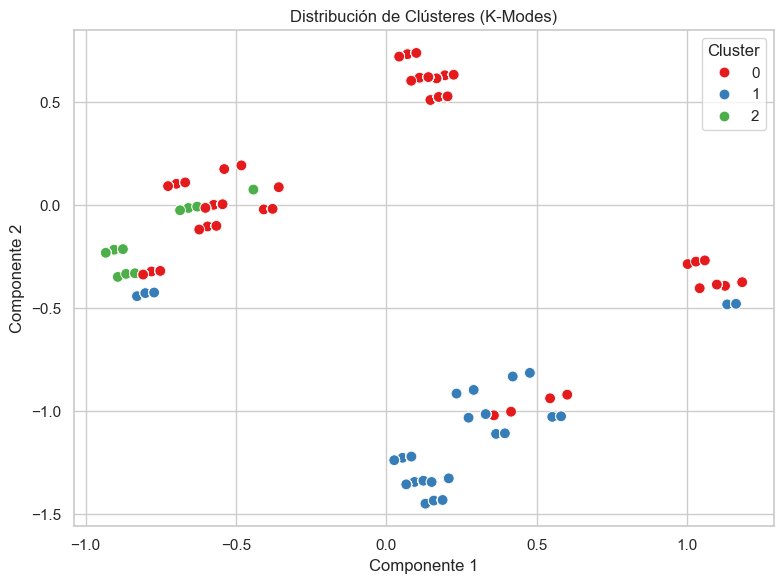

In [37]:
# Selecciona tus variables discretas
discretas = df[['Gears', 'age', 'Previous_Owners', 'Inspection_new']].dropna()

# Asegura que sean tipo "object" o "category"
discretas = discretas.astype(str)

# Aplicar K-Modes
n_clusters = 3
kmod = KModes(n_clusters=n_clusters, init='Cao', n_init=5, verbose=1)
discretas['Cluster_KModes'] = kmod.fit_predict(discretas)

# Mostrar resultados
print("=== Frecuencia de autos por clúster (K-Modes) ===")
print(discretas['Cluster_KModes'].value_counts())

# Visualización: contamos proporciones por clúster
resumen = discretas.groupby('Cluster_KModes').agg(lambda x: x.value_counts().index[0])
print("\n=== Categorías predominantes por clúster ===")
print(resumen)

# Visualización 2D (usamos PCA tras one-hot encoding)
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
X_encoded = encoder.fit_transform(discretas.drop('Cluster_KModes', axis=1)).toarray()
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_encoded)
discretas['PC1'] = componentes[:, 0]
discretas['PC2'] = componentes[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=discretas, x='PC1', y='PC2', hue='Cluster_KModes', palette='Set1', s=60)
plt.title('Distribución de Clústeres (K-Modes)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:18px">
<b>Análisis factorial</b><br>
</div>


 🔹 MATRIZ DE CORRELACIONES:
                 price     km  hp_kW  Displacement_cc  Weight_kg  cons_comb
price            1.000 -0.399  0.696            0.282      0.468      0.272
km              -0.399  1.000  0.004            0.307      0.147     -0.300
hp_kW            0.696  0.004  1.000            0.597      0.638      0.389
Displacement_cc  0.282  0.307  0.597            1.000      0.563      0.038
Weight_kg        0.468  0.147  0.638            0.563      1.000      0.089
cons_comb        0.272 -0.300  0.389            0.038      0.089      1.000

🔹 CARGAS FACTORIALES:
                 Factor 1  Factor 2  Factor 3
price               0.602     0.795     0.056
km                  0.221    -0.653    -0.204
hp_kW               0.852     0.208     0.260
Displacement_cc     0.757    -0.216    -0.005
Weight_kg           0.746     0.024     0.001
cons_comb           0.111     0.192     0.973

🔹 VARIANZA EXPLICADA:
          Varianza  Proporción  Acumulada
Factor 1     2.279       0.38

C:\Users\Nitro V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Figure size 700x500 with 0 Axes>

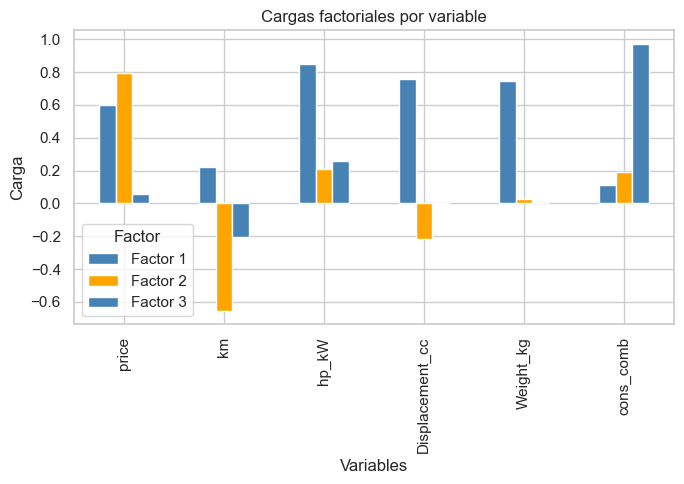

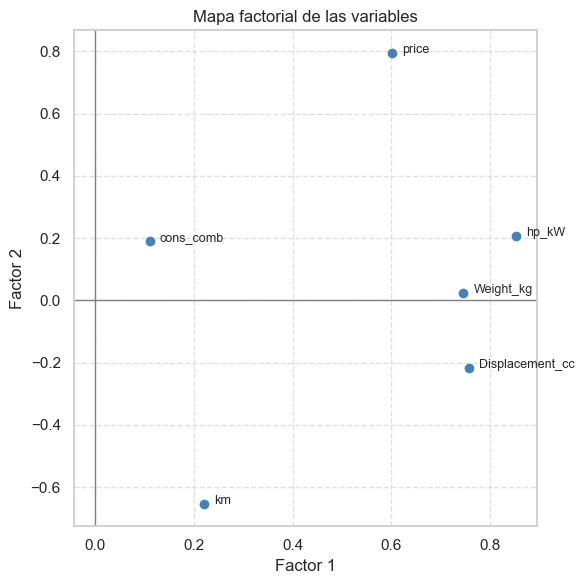

In [38]:
# Análisis factorial
# Selección de variables continuas
variables = ['price', 'km', 'hp_kW', 'Displacement_cc', 'Weight_kg', 'cons_comb']
df_cont = df[variables].dropna()

# Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cont)
X_df = pd.DataFrame(X_scaled, columns=variables)

# Matriz de correlaciones
print("\n 🔹 MATRIZ DE CORRELACIONES:")
print(X_df.corr().round(3))

# Análisis factorial (3 factores)
fa = FactorAnalyzer(n_factors=3, rotation='varimax')
fa.fit(X_scaled)

# Cargas factoriales
cargas = pd.DataFrame(fa.loadings_, index=variables, columns=['Factor 1', 'Factor 2','Factor 3'])
print("\n🔹 CARGAS FACTORIALES:")
print(cargas.round(3))

# Varianza explicada
var_exp = fa.get_factor_variance()
varianza_df = pd.DataFrame({
    'Varianza': var_exp[0],
    'Proporción': var_exp[1],
    'Acumulada': var_exp[2]
}, index=[f'Factor {i+1}' for i in range(len(var_exp[0]))])
print("\n🔹 VARIANZA EXPLICADA:")
print(varianza_df.round(3))

# Visualización de las cargas factoriales
plt.figure(figsize=(7, 5))
cargas.plot(kind='bar', figsize=(7, 5), color=['steelblue', 'orange'])
plt.title('Cargas factoriales por variable')
plt.xlabel('Variables')
plt.ylabel('Carga')
plt.legend(title='Factor')
plt.tight_layout()
plt.show()

# Gráfico de dispersión de variables en el plano factorial
plt.figure(figsize=(6,6))
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
for i, var in enumerate(variables):
    plt.scatter(cargas.iloc[i,0], cargas.iloc[i,1], color='steelblue')
    plt.text(cargas.iloc[i,0]+0.02, cargas.iloc[i,1], var, fontsize=9)
plt.title('Mapa factorial de las variables')
plt.xlabel('Factor 1')
plt.ylabel('Factor 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### <span style="color:black;"><strong>Interpretación</strong></span>

Cada factor agrupa variables con altas cargas 

- Factor 1: Desempeño del vehículo: Altas cargas en: hp_kW (0.852), Displacement_cc (0.757), Weight_kg (0.746) y price (0.602); Representa potencia y características físicas asociadas al desempeño y costo.

- Factor 2: Uso y kilometraje: Cargas destacadas: price (0.795) positiva y km (-0.653) negativa; los autos más nuevos o menos usados valen más.

- Factor 3: Carga casi exclusiva de cons_comb (0.973); representa eficiencia o consumo de combustible, independiente de potencia o uso.

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:20px">
<b>Detección y análisis de atípicos</b><br>
</div>

<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:18px">
<b>IQR</b><br>
</div>

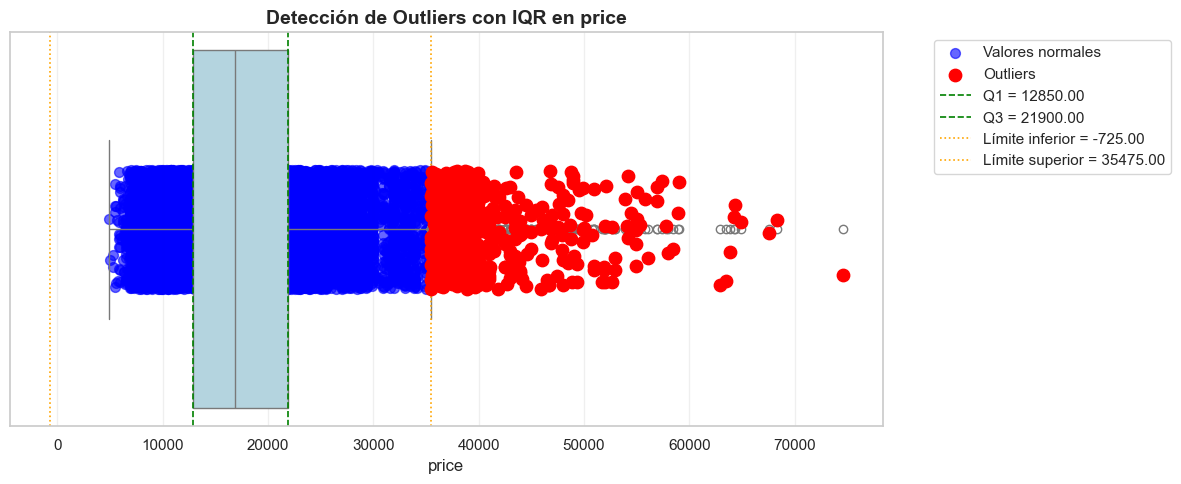

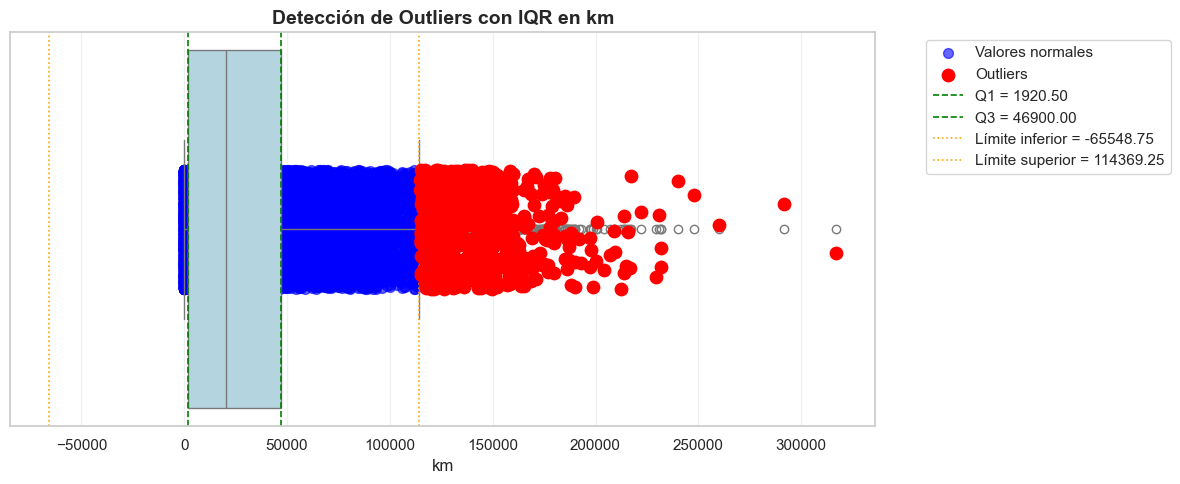

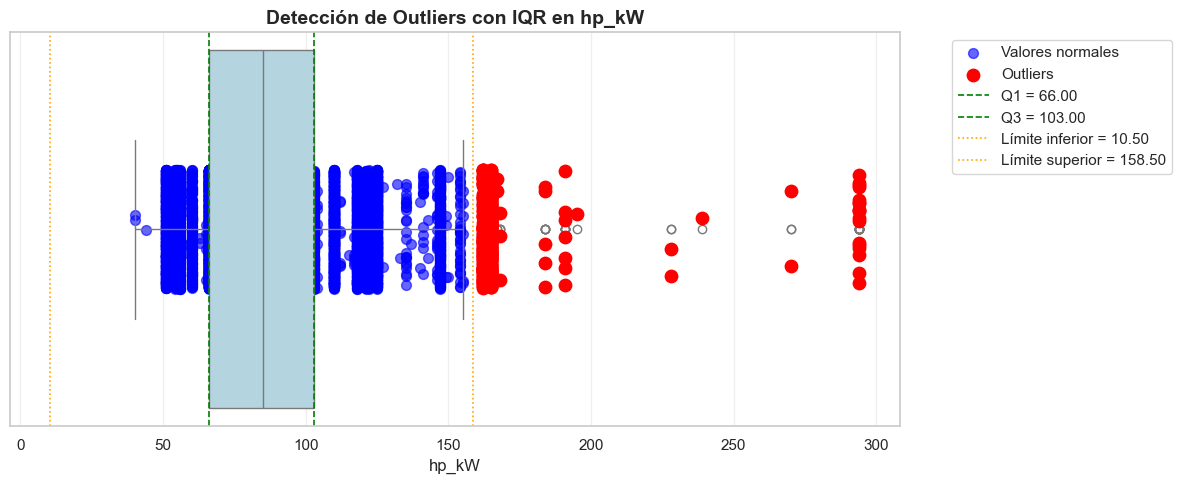

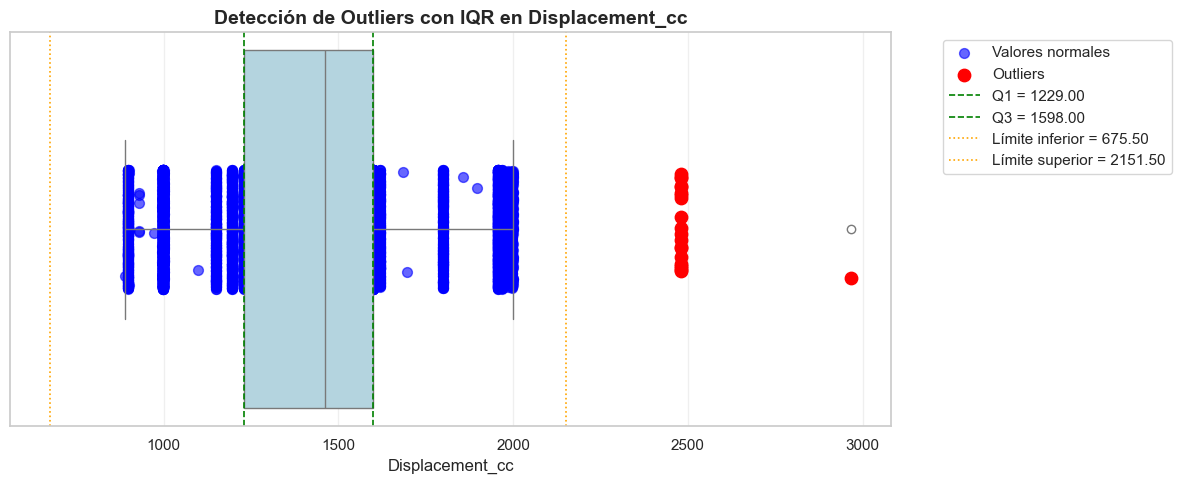

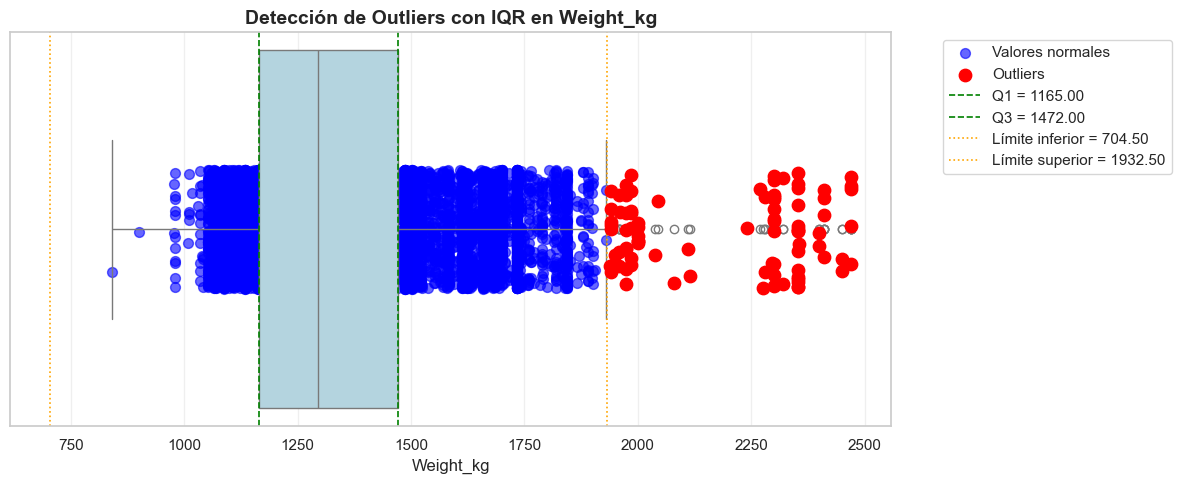

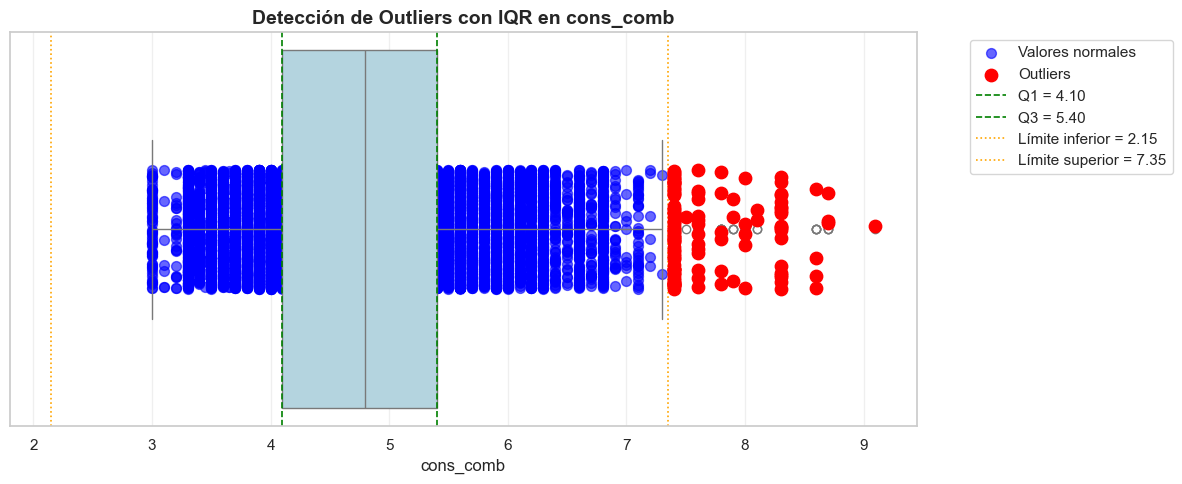

In [39]:
# Recorremos cada variable continua
for var in variables_continuas:
    if var in df.columns:
        data = df[var].dropna()

        # Cálculo de IQR
        Q1, Q3 = np.percentile(data, [25, 75])
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Identificar outliers y valores normales
        outliers_iqr = data[(data < limite_inferior) | (data > limite_superior)]
        normales_iqr = data[(data >= limite_inferior) & (data <= limite_superior)]

        # Gráfico
        plt.figure(figsize=(12, 5))
        sns.boxplot(x=data, color="lightblue", width=0.3)

        plt.scatter(normales_iqr, np.random.uniform(-0.05, 0.05, size=len(normales_iqr)),
                    color="blue", s=50, alpha=0.6, label="Valores normales")
        plt.scatter(outliers_iqr, np.random.uniform(-0.05, 0.05, size=len(outliers_iqr)),
                    color="red", s=80, zorder=5, label="Outliers")

        plt.axvline(Q1, color="green", linestyle="--", linewidth=1.2, label=f"Q1 = {Q1:.2f}")
        plt.axvline(Q3, color="green", linestyle="--", linewidth=1.2, label=f"Q3 = {Q3:.2f}")
        plt.axvline(limite_inferior, color="orange", linestyle=":", linewidth=1.2, label=f"Límite inferior = {limite_inferior:.2f}")
        plt.axvline(limite_superior, color="orange", linestyle=":", linewidth=1.2, label=f"Límite superior = {limite_superior:.2f}")

        plt.title(f"Detección de Outliers con IQR en {var}", fontsize=14, weight="bold")
        plt.xlabel(var)
        plt.yticks([])  # quitar eje Y porque no aporta
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.grid(alpha=0.3, axis="x")
        plt.tight_layout()
        plt.show()


<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:18px">
<b>Z-score</b><br>
</div>

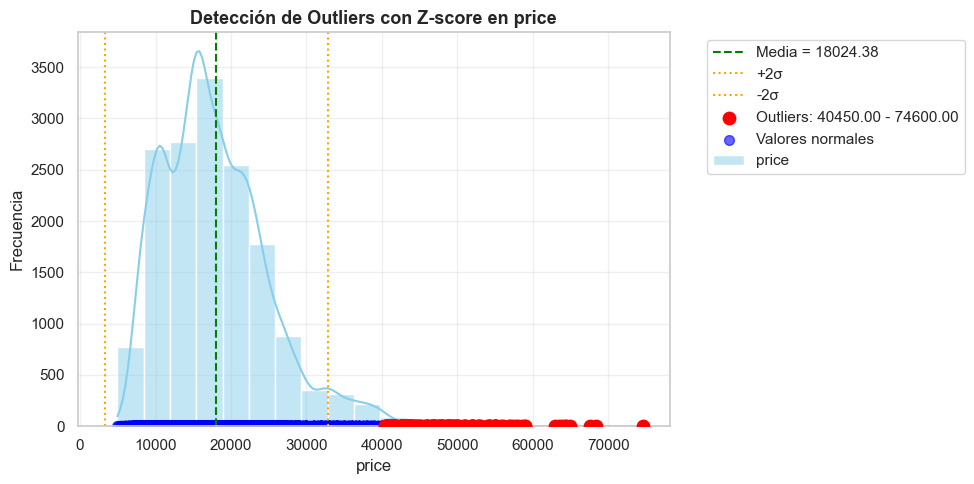

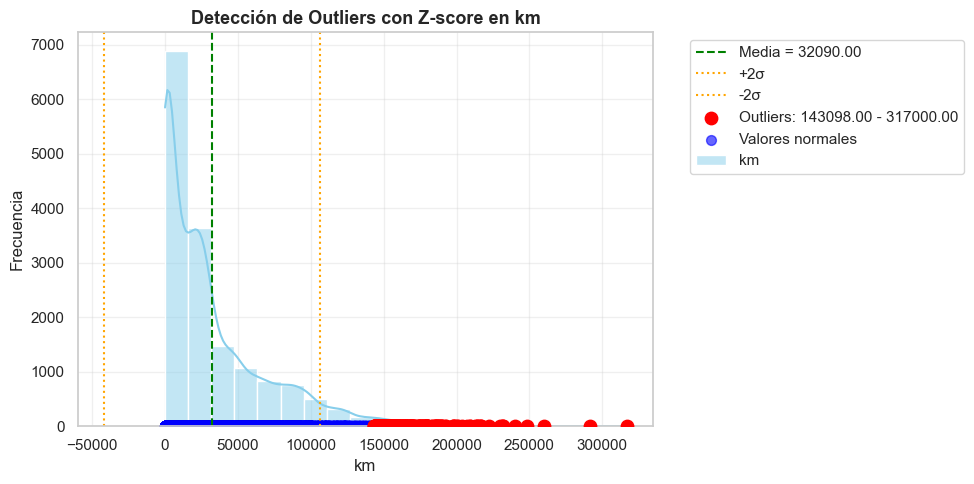

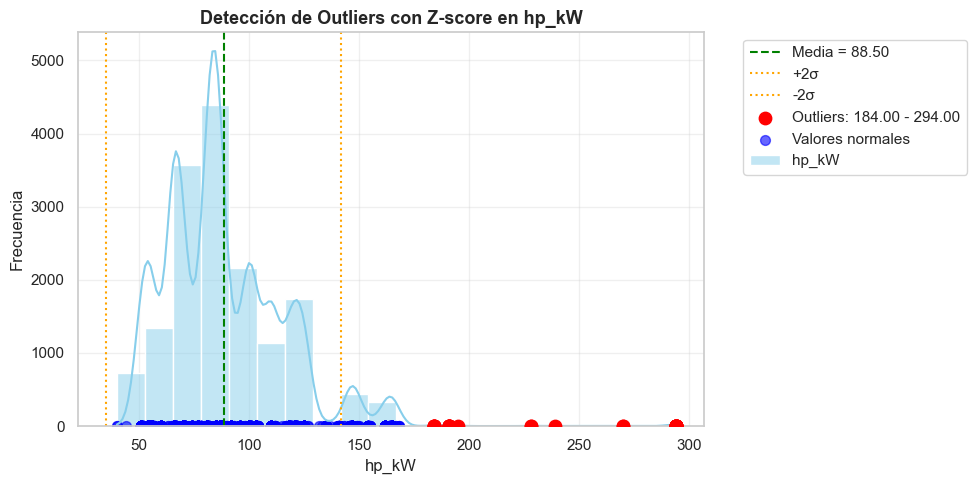

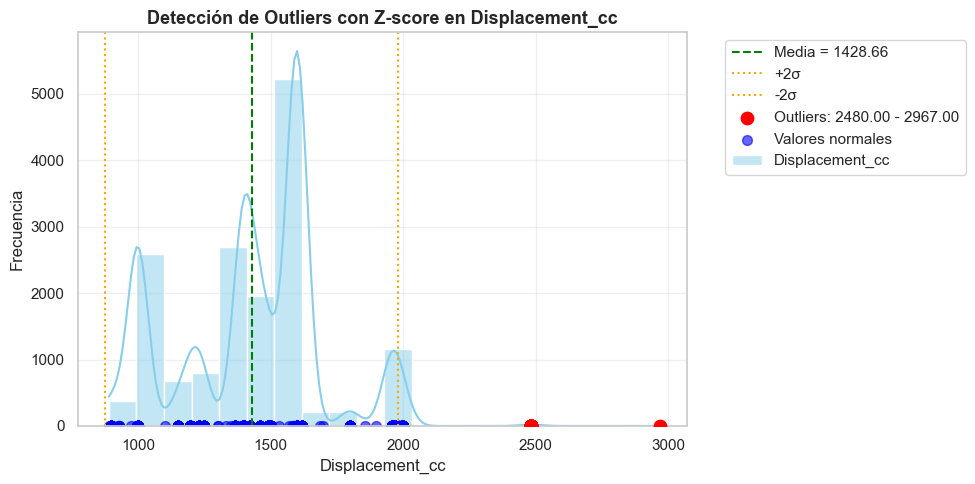

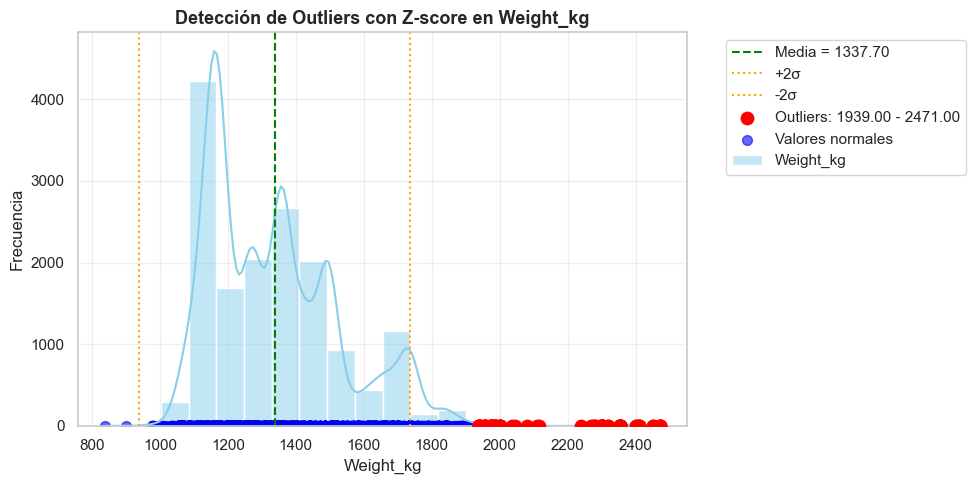

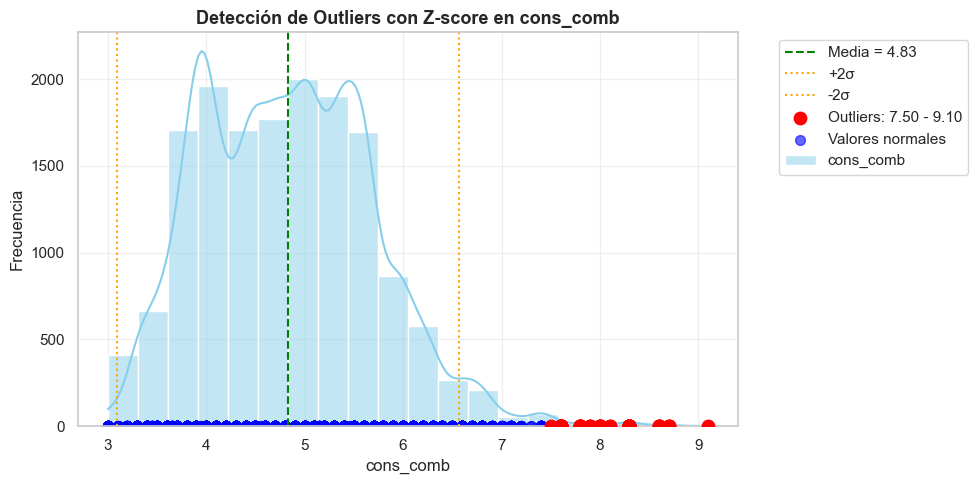

In [40]:
for var in variables_continuas:
    if var in df.columns:
        data = df[var].dropna()

        # Cálculo de Z-score
        z_scores = stats.zscore(data)
        outliers_z = data[np.abs(z_scores) > 3]
        normales = data[np.abs(z_scores) <= 3]

        # Visualización
        plt.figure(figsize=(10, 5))
        sns.histplot(data, bins=20, kde=True, color="skyblue", label=var)
        
        plt.axvline(np.mean(data), color="green", linestyle="--", label=f"Media = {np.mean(data):.2f}")
        plt.axvline(np.mean(data) + 2*np.std(data), color="orange", linestyle=":", label="+2σ")
        plt.axvline(np.mean(data) - 2*np.std(data), color="orange", linestyle=":", label="-2σ")
        
        # Outliers como rango
        if len(outliers_z) > 0:
            rango_outliers = f"{outliers_z.min():.2f} - {outliers_z.max():.2f}"
            plt.scatter(outliers_z, np.random.uniform(0, 0.05, size=len(outliers_z)),
                        color="red", s=80, zorder=5, label=f"Outliers: {rango_outliers}")

        # Valores normales (sin leyenda repetida)
        plt.scatter(normales, np.random.uniform(0, 0.05, size=len(normales)),
                    color="blue", s=50, alpha=0.6, label="Valores normales")
        
        plt.title(f"Detección de Outliers con Z-score en {var}", fontsize=13, weight="bold")
        plt.xlabel(var)
        plt.ylabel("Frecuencia")
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()



<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:18px">
<b>Grubbs y DBSCAN</b><br>
</div>

C:\Users\Nitro V15\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


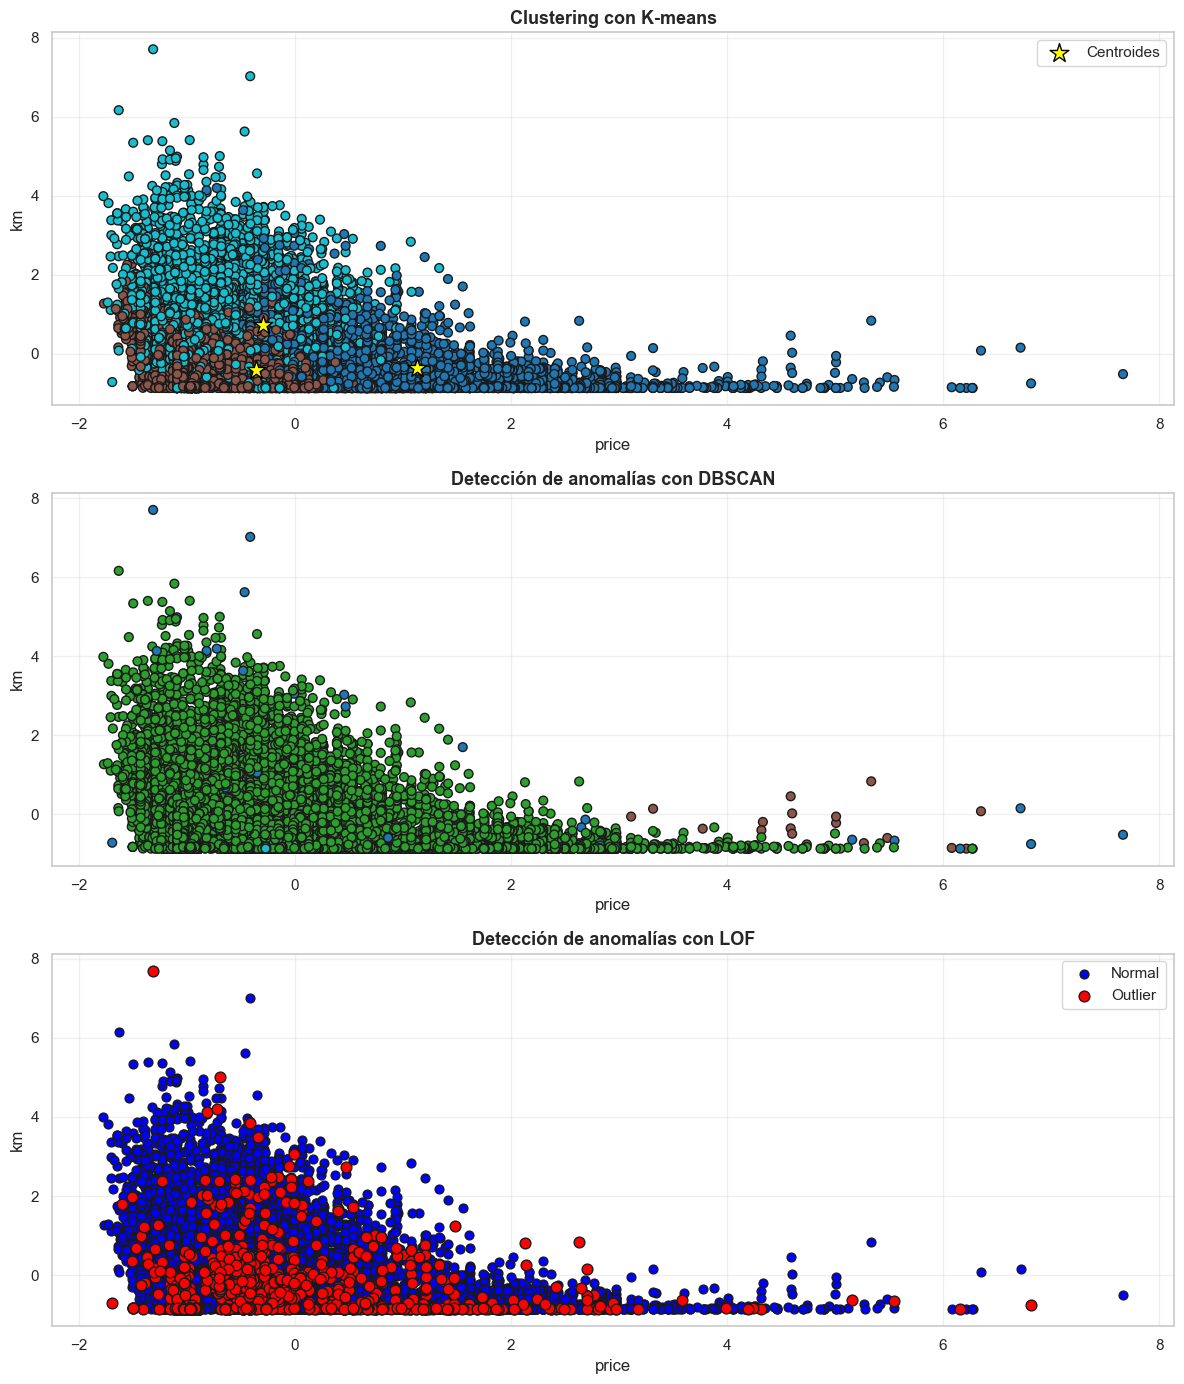

In [41]:
# Selección y estandarización
X = df[variables_continuas].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

# DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=6)
labels_dbscan = dbscan.fit_predict(X_scaled)

# LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
labels_lof = lof.fit_predict(X_scaled)

# Visualización: mostramos en 2D usando las dos primeras variables
plt.figure(figsize=(12, 14))

#  K-means
plt.subplot(3, 1, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_kmeans, cmap="tab10", s=40, edgecolor="k")
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="yellow", s=200, edgecolor="black", marker="*", label="Centroides")
plt.title("Clustering con K-means", fontsize=13, weight="bold")
plt.xlabel(variables_continuas[0]); plt.ylabel(variables_continuas[1])
plt.legend(); plt.grid(alpha=0.3)

#  DBSCAN
plt.subplot(3, 1, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_dbscan, cmap="tab10", s=40, edgecolor="k")
plt.title("Detección de anomalías con DBSCAN", fontsize=13, weight="bold")
plt.xlabel(variables_continuas[0]); plt.ylabel(variables_continuas[1])
plt.grid(alpha=0.3)

# LOF
plt.subplot(3, 1, 3)
plt.scatter(X_scaled[labels_lof == 1, 0], X_scaled[labels_lof == 1, 1],
            c="blue", s=40, label="Normal", edgecolor="k")
plt.scatter(X_scaled[labels_lof == -1, 0], X_scaled[labels_lof == -1, 1],
            c="red", s=60, label="Outlier", edgecolor="k")
plt.title("Detección de anomalías con LOF", fontsize=13, weight="bold")
plt.xlabel(variables_continuas[0]); plt.ylabel(variables_continuas[1])
plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### <span style="color:black;"><strong>Interpretación</strong></span>

Referente a valores atípicos:
- price y km son las variables con mayor presencia de outliers.
- Muchos de estos valores no son errores, sino autos especiales (de alta gama o muy usados).
- hp_kW, Weight_kg y Displacement_cc muestran distribuciones más homogéneas.

Qué hacer con los atípicos:

- Autos de lujo o deportivos (precios muy altos, alta potencia): se deben mantener puesto que, representan una categoría válida del mercado.
- Kilometrajes extremadamente altos:como son reales, pueden mantenerse; o se puede intentar transformar con (log).



<div style="background-color:#E3F2FD; border-left:6px solid #1565C0; padding:10px 15px; border-radius:6px; margin-bottom:15px; font-size:20px">
<b>Conclusiones Generales</b><br>
</div>

- El análisis exploratorio inicial permitió comprender la estructura y comportamiento general del conjunto de datos.
- Las variables continuas como price, km, hp_kW, Displacement_cc, Weight_kg y cons_comb mostraron una amplia variabilidad, evidenciando la diversidad de vehículos en el mercado (desde autos económicos hasta de alta gama).
- Se identificó una distribución asimétrica positiva en variables como price y km, lo que indica la presencia de vehículos con precios o kilometrajes excepcionalmente altos.
- Por su parte, las variables discretas (Gears, age, Previous_Owners, Inspection_new) mostraron concentraciones en pocos valores, lo cual sugiere que la mayoría de los vehículos tienen configuraciones y estados relativamente similares.
- El Análisis de Componentes Principales (PCA) permitió reducir la dimensionalidad del conjunto de variables continuas.
- Los dos primeros componentes principales explicaron más del 70% de la varianza total, lo cual indica que gran parte de la información puede resumirse en pocas dimensiones.
- El primer componente (PC1) estuvo asociado con la potencia (hp_kW), cilindraje (Displacement_cc) y peso (Weight_kg), mientras que el segundo componente (PC2) se relacionó principalmente con el kilometraje (km) y el precio (price).
- Esto demuestra que las características técnicas y el nivel de uso del vehículo son los factores que más diferencian a los autos en el conjunto de datos.
- Se aplicaron los métodos IQR (rango intercuartílico) y Z-Score, además de DBSCAN para identificar observaciones atípicas multivariadas.
- Los resultados mostraron outliers principalmente en las variables price y km, correspondientes a vehículos de lujo o con kilometraje extremo.
